# 23CSE301 Machine Learning — Capstone Project
# Regression Track — Indian Health Insurance Claims

### Problem statement
Given a health-insurance policyholder's demographic profile, lifestyle and health-risk indicators, policy
details, and the circumstances of their hospitalisation, predict the **`total_claim_amount`** — the rupee
value of the claim filed against the policy.

| Item | Value |
|---|---|
| Dataset | `indian_health_insurance_claims_dataset.csv` |
| Rows × Columns | 8,000 × 38 |
| **Regression target** | `total_claim_amount` (continuous, ₹) |
| Task type | Supervised regression |
| Algorithms | 10 (as per Section 3.1 of the guidelines) |
| Metrics | R², RMSE, MAE + 5-fold cross-validated R² for the two best models |
| Split | 80:20, stratified on target deciles |
| Random seed | `42` throughout |

Declaration of assistance


According to Section 7.5 , code scaffolding with the help of Generative tools
is permitted.
We have used Claude AI's assistance, however the analysis, interpretation, and feature engineering decisions have been completely done by us.

In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Reproducibility (guideline 7.1)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot styling (guideline 7.3 — colourblind-friendly palette)
sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print("Libraries loaded. RANDOM_STATE =", RANDOM_STATE)

Libraries loaded. RANDOM_STATE = 42


---
# Section A — Dataset & EDA


In [5]:
# ---- A1: Load the dataset ----
df = pd.read_csv('/content/indian_health_insurance_claims_dataset.csv')

print("Shape (rows, columns):", df.shape)
print("\nColumns:")
print(list(df.columns))
df.head()

Shape (rows, columns): (8000, 38)

Columns:
['policy_id', 'customer_name', 'gender', 'age', 'marital_status', 'state', 'city', 'pincode', 'aadhaar_masked', 'occupation_type', 'annual_income_inr', 'bmi', 'tobacco_usage', 'alcohol_units_per_week', 'physical_activity_level', 'diet_type', 'has_diabetes', 'has_hypertension', 'family_history_cardiac', 'stress_level_score', 'policy_type', 'sum_insured', 'policy_start_date', 'claim_date', 'hospital_name', 'hospital_tier', 'room_category', 'icu_days', 'length_of_stay', 'cashless_claim', 'agent_channel', 'hospital_bill_amount', 'pre_hospitalization_expense', 'post_hospitalization_expense', 'non_payable_items', 'deductible_amount', 'co_pay_amount', 'total_claim_amount']


,policy_id,customer_name,gender,age,marital_status,state,city,pincode,aadhaar_masked,occupation_type,annual_income_inr,bmi,tobacco_usage,alcohol_units_per_week,physical_activity_level,diet_type,has_diabetes,has_hypertension,family_history_cardiac,stress_level_score,policy_type,sum_insured,policy_start_date,claim_date,hospital_name,hospital_tier,room_category,icu_days,length_of_stay,cashless_claim,agent_channel,hospital_bill_amount,pre_hospitalization_expense,post_hospitalization_expense,non_payable_items,deductible_amount,co_pay_amount,total_claim_amount
0,IND103304,Alka Mukhopadhyay,F,36,Divorced,Tamil Nadu,Chennai,847016,XXXX-XXXX-6575,Business,823300.22,28.779126,smoking,4,low,non-veg,0.0,0.0,0,NaN,individual,2000000,2019-09-13,2022-04-23,"Lall, Bumb and Dua Hospital",private_small,general,2,6,yes,online,160039.77,15092.716958,14816.007640,5229.900734,6634.961901,26405.574579,"₹151,678"
1,IND101987,Gautami Chanda,F,39,married,Karnataka,Bengaluru,432335,XXXX-XXXX-2872,Retired,989128.77,30.729990,none,2,low,veg,0.0,1.0,0,4.751607,individual,2000000,2021-12-11,2023-11-04,"Rai, Randhawa and Ray Hospital",private_small,deluxe,3,6,no,bancassurance,173704.83,14920.655851,10384.480861,12756.023431,6987.996116,16771.482336,162494.46
2,IND104725,Ridhi Wable,Male,48,married,Karnataka,Bengaluru,807064,XXXX-XXXX-9125,Self-employed,717704.79,28.208313,smoking,0,moderate,vegan,0.0,0.0,1,4.786732,family_floater,500000,2021-05-20,2023-03-20,Kadakia PLC Hospital,private_corporate,semi-private,3,5,yes,agent,220261.47,16202.882187,19974.634737,9624.570612,10524.495687,31255.241298,205034.68
3,IND105031,Ethan Shankar,M,46,Widowed,Tamil Nadu,Coimbatore,900329,XXXX-XXXX-1493,Self-employed,795085.69,20.424576,chewing,4,low,non-veg,0.0,0.0,0,7.677186,family_floater,2000000,2020-05-11,2021-09-06,Apte-Dhawan Hospital,private_corporate,private,0,5,no,aggregator,128736.67,9340.872259,6760.021670,2622.298761,6400.820348,21994.193710,512986.56
4,IND107599,Logan Chaudhry,F,18,Married,Tamil Nadu,Chennai,466064,286274455107,Unemployed,501550.91,31.507076,none,4,low,veg,0.0,0.0,0,4.002162,individual,1000000,2021-04-26,2024-07-25,"Shan, Rao and Sekhon Hospital",private_corporate,private,2,5,yes,aggregator,148014.44,16595.311362,17123.418402,11346.864183,1550.856123,21866.765755,"₹146,969"


In [6]:
# ---- A1: Data types and memory footprint ----
print("=== Data types ===")
print(df.dtypes.to_string())
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

=== Data types ===
policy_id                        object
customer_name                    object
gender                           object
age                               int64
marital_status                   object
state                            object
city                             object
pincode                           int64
aadhaar_masked                   object
occupation_type                  object
annual_income_inr                object
bmi                             float64
tobacco_usage                    object
alcohol_units_per_week            int64
physical_activity_level          object
diet_type                        object
has_diabetes                    float64
has_hypertension                float64
family_history_cardiac            int64
stress_level_score              float64
policy_type                      object
sum_insured                       int64
policy_start_date                object
claim_date                       object
hospital_name        

In [7]:
# ---- A1: Missing-value audit ----
missing = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2)
})
missing = missing[missing['missing_count'] > 0].sort_values('missing_count', ascending=False)

print("=== Columns containing missing values ===")
print(missing.to_string())
print(f"\nColumns with no missing values: {(df.isna().sum() == 0).sum()} of {df.shape[1]}")
print(f"Rows with at least one missing value: {df.isna().any(axis=1).sum()}")

=== Columns containing missing values ===
                    missing_count  missing_pct
annual_income_inr             560         7.00
bmi                           560         7.00
stress_level_score            560         7.00
has_hypertension              391         4.89
has_diabetes                  383         4.79

Columns with no missing values: 33 of 38
Rows with at least one missing value: 2176


> Missing values are confined to five columns and are mild in volume: `annual_income_inr`, `bmi` and
> `stress_level_score` are each missing on 560 rows (7.0%),

and the two medical screening flags
> `has_hypertension` (391) and `has_diabetes` (383) on roughly 4.8%.

 No column is sparse enough to justify
> dropping, and no row is missing enough to justify deletion — 8,000 rows is not so large that we can afford
> to throw away 7% of them.

All five are therefore imputed.

In [8]:
# Several columns that should be numeric were read as text.
print("=== Columns that look numeric but were read as object/string ===")
for col in ['total_claim_amount', 'hospital_bill_amount', 'annual_income_inr']:
    print(f"\n{col}  (dtype = {df[col].dtype})")
    print("  sample values:", df[col].dropna().unique()[:6].tolist())

print("\n=== Inconsistent categorical encodings ===")
print("gender         :", df['gender'].value_counts(dropna=False).to_dict())
print("marital_status :", df['marital_status'].value_counts(dropna=False).to_dict())

=== Columns that look numeric but were read as object/string ===

total_claim_amount  (dtype = object)
  sample values: ['₹151,678', '162494.46', '205034.68', '512986.56', '₹146,969', '103305.83']

hospital_bill_amount  (dtype = object)
  sample values: ['160039.77', '173704.83', '220261.47', '128736.67', '148014.44', '104387.47']

annual_income_inr  (dtype = object)
  sample values: ['823300.22', '989128.77', '717704.79', '795085.69', '501550.91', '1177278.21']

=== Inconsistent categorical encodings ===
gender         : {'female': 1363, 'F': 1350, 'Male': 1336, 'male': 1333, 'Female': 1327, 'M': 1291}
marital_status : {'Widowed': 1682, 'married': 1634, 'Married': 1571, 'Single': 1559, 'Divorced': 1554}


> 1. **`total_claim_amount` — the regression target — was loaded as text**, because roughly 745 of the 8,000
>    values are formatted like `'₹151,678'` while the rest are plain numbers such as `205034.68`. Had we not
>    caught this, every statistic, plot and model in this notebook would have been wrong or would have crashed.
>    The same problem affects `hospital_bill_amount` (≈786 rows).


> 2. **`annual_income_inr` mixes two unit systems**: plain rupee figures (`'823300.22'`) and the Indian
>    shorthand `'4.2 LPA'` (Lakhs Per Annum, where 1 lakh = 100,000). Parsing `'4.2 LPA'` naively would give
>    ₹4.2 instead of ₹420,000 — an error of five orders of magnitude on 634 rows.


> 3. **`gender` has 6 distinct strings for 2 real categories** (`'M'`, `'male'`, `'Male'`, `'F'`, `'female'`,
>    `'Female'`), and `marital_status` has 5 strings for 4 categories (`'married'` vs `'Married'`).
>    One-hot encoding this as-is would silently split one category across several dummy columns, diluting the
>    signal in each.


> All three are fixed in the next three cells.

In [9]:
# ---- A1/B1: Fix 1 — parse currency-formatted columns into real numbers ----
def clean_currency(s):
    # Strip rupee symbols and thousands separators, return float
    if pd.isna(s):
        return np.nan
    s = str(s).replace('\u20b9', '').replace(',', '').strip()
    try:
        return float(s)
    except ValueError:
        return np.nan

def clean_income(s):
    # Handle the Indian 'LPA' (Lakhs Per Annum) notation: 1 lakh = 100,000
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    if 'LPA' in s.upper():
        return float(s.upper().replace('LPA', '').strip()) * 100_000
    return clean_currency(s)

rupee_claim  = df['total_claim_amount'].astype(str).str.contains('\u20b9').sum()
rupee_bill   = df['hospital_bill_amount'].astype(str).str.contains('\u20b9').sum()
lpa_income   = df['annual_income_inr'].astype(str).str.upper().str.contains('LPA').sum()
print(f"Rows needing repair — total_claim_amount: {rupee_claim}, "
      f"hospital_bill_amount: {rupee_bill}, annual_income_inr (LPA): {lpa_income}")

df['total_claim_amount']   = df['total_claim_amount'].apply(clean_currency)
df['hospital_bill_amount'] = df['hospital_bill_amount'].apply(clean_currency)
df['annual_income_inr']    = df['annual_income_inr'].apply(clean_income)

print("\nParse failures introduced by cleaning (should be 0, except pre-existing gaps):")
print(f"  total_claim_amount   : {df['total_claim_amount'].isna().sum()}")
print(f"  hospital_bill_amount : {df['hospital_bill_amount'].isna().sum()}")
print(f"  annual_income_inr    : {df['annual_income_inr'].isna().sum()}  "
      f"(matches the 560 originally missing — no new failures)")
print("\nDtypes are now:", df[['total_claim_amount', 'hospital_bill_amount', 'annual_income_inr']].dtypes.tolist())

Rows needing repair — total_claim_amount: 745, hospital_bill_amount: 786, annual_income_inr (LPA): 634

Parse failures introduced by cleaning (should be 0, except pre-existing gaps):
  total_claim_amount   : 0
  hospital_bill_amount : 0
  annual_income_inr    : 560  (matches the 560 originally missing — no new failures)

Dtypes are now: [dtype('float64'), dtype('float64'), dtype('float64')]


In [10]:
# ---- A1/B1: Fix 2 — normalise inconsistent categorical casing ----
print("gender BEFORE :", df['gender'].value_counts().to_dict())
df['gender'] = (df['gender'].str.strip().str.lower()
                .map({'m': 'male', 'f': 'female', 'male': 'male', 'female': 'female'}))
print("gender AFTER  :", df['gender'].value_counts().to_dict())

print("\nmarital_status BEFORE :", df['marital_status'].value_counts().to_dict())
df['marital_status'] = df['marital_status'].str.strip().str.lower()
print("marital_status AFTER  :", df['marital_status'].value_counts().to_dict())

print("\nUnmapped gender values (should be 0):", df['gender'].isna().sum())

gender BEFORE : {'female': 1363, 'F': 1350, 'Male': 1336, 'male': 1333, 'Female': 1327, 'M': 1291}
gender AFTER  : {'female': 4040, 'male': 3960}

marital_status BEFORE : {'Widowed': 1682, 'married': 1634, 'Married': 1571, 'Single': 1559, 'Divorced': 1554}
marital_status AFTER  : {'married': 3205, 'widowed': 1682, 'single': 1559, 'divorced': 1554}

Unmapped gender values (should be 0): 0


In [11]:
# ---- A1: Target audit and numeric summary (now that the data is genuinely numeric) ----
TARGET = 'total_claim_amount'

print("=== Target:", TARGET, "===")
print(df[TARGET].describe().round(2).to_string())
print(f"\nSkewness : {df[TARGET].skew():.2f}")
print(f"Kurtosis : {df[TARGET].kurtosis():.2f}")
print(f"Zero or negative values: {(df[TARGET] <= 0).sum()}")

print("\n=== Numeric summary of all numeric columns ===")
df.describe().T.round(2)

=== Target: total_claim_amount ===
count       8000.00
mean      121636.20
std        65843.87
min         5000.00
25%        79352.72
50%       111817.29
75%       152470.28
max      1329765.90

Skewness : 3.32
Kurtosis : 33.32
Zero or negative values: 0

=== Numeric summary of all numeric columns ===


,count,mean,std,min,25%,50%,75%,max
age,8000.0,41.77,15.10,18.00,30.00,41.00,52.00,85.00
pincode,8000.0,541655.03,264560.69,13587.00,309657.50,538704.50,773501.00,999797.00
annual_income_inr,7440.0,829351.56,451115.65,150000.00,512249.68,730043.72,1033076.94,4703966.62
bmi,7440.0,25.99,4.91,15.00,22.54,26.00,29.33,43.68
alcohol_units_per_week,8000.0,3.00,1.73,0.00,2.00,3.00,4.00,11.00
has_diabetes,7617.0,0.22,0.41,0.00,0.00,0.00,0.00,1.00
has_hypertension,7609.0,0.27,0.44,0.00,0.00,0.00,1.00,1.00
family_history_cardiac,8000.0,0.34,0.47,0.00,0.00,0.00,1.00,1.00
stress_level_score,7440.0,5.03,1.94,1.00,3.69,5.03,6.38,10.00
sum_insured,8000.0,1746775.00,1715204.75,300000.00,500000.00,1000000.00,2000000.00,5000000.00


In [12]:
# ---- A1: Cardinality of every non-numeric column ----
cat_like = df.select_dtypes(include=['object', 'string']).columns.tolist()
print("=== Cardinality of non-numeric columns ===")
for c in cat_like:
    print(f"  {c:26s} {df[c].nunique():>6} unique")

print("\n=== Distribution of the main categorical features ===")
for c in ['hospital_tier', 'room_category', 'policy_type', 'agent_channel', 'state']:
    print(f"\n{c}:")
    print(df[c].value_counts(dropna=False).to_string())

=== Cardinality of non-numeric columns ===
  policy_id                    8000 unique
  customer_name                7876 unique
  gender                          2 unique
  marital_status                  4 unique
  state                           6 unique
  city                           12 unique
  aadhaar_masked               5707 unique
  occupation_type                 6 unique
  tobacco_usage                   4 unique
  physical_activity_level         3 unique
  diet_type                       4 unique
  policy_type                     3 unique
  policy_start_date            2141 unique
  claim_date                   3097 unique
  hospital_name                7188 unique
  hospital_tier                   3 unique
  room_category                   4 unique
  cashless_claim                  2 unique
  agent_channel                   4 unique

=== Distribution of the main categorical features ===

hospital_tier:
hospital_tier
private_corporate    4038
private_small        2764
gov

> After repair the dataset is 8,000 claims with a genuinely continuous target. `total_claim_amount` ranges from
> ₹5,000 to ₹1,329,766 with a median near ₹111,817 and a **skewness of ≈ 3.3** — strongly right-skewed, which is
> exactly what medical cost data looks like: most hospitalisations are routine, a minority are catastrophic.


> The cardinality listing also identifies the identifier columns: `policy_id` is unique per row (8,000/8,000),
> `hospital_name` has 7,188 distinct values and `customer_name` 7,876. These are labels, not features, and are
> excluded from modelling.

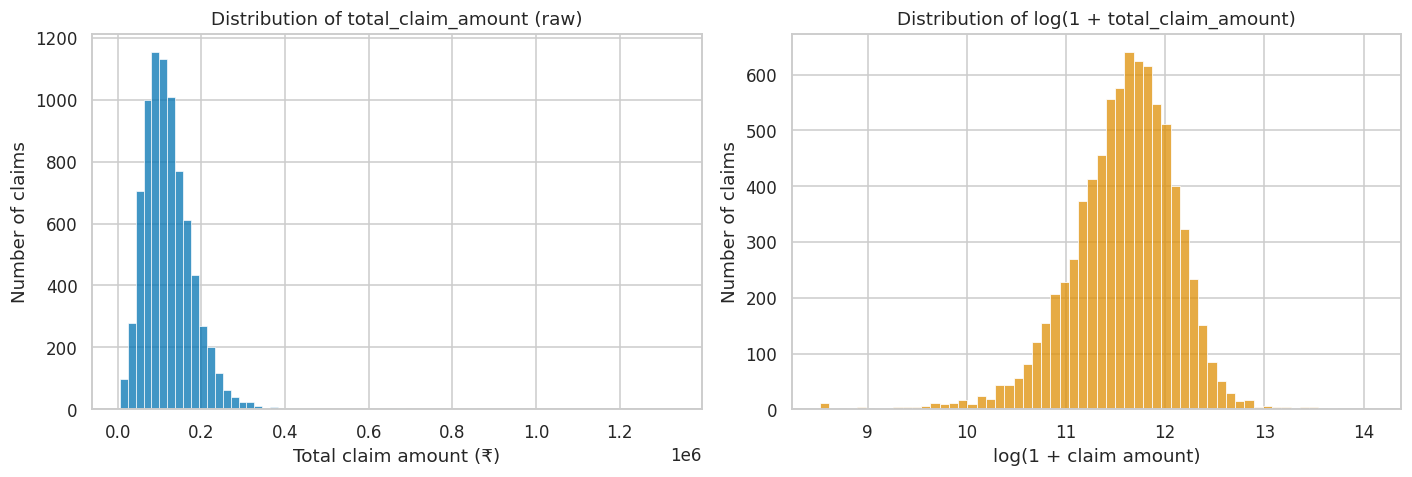

Raw skewness         : 3.32
Log-transformed skew : -0.85

Upper-tail percentiles (₹):
0.500     111817.0
0.750     152470.0
0.900     194743.0
0.950     224799.0
0.990     311398.0
0.999     702389.0
1.000    1329766.0


In [13]:
# ---- A2: Target distribution (raw and log scale) ----
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df[TARGET], bins=70, ax=axes[0], color='#0173B2')
axes[0].set_title('Distribution of total_claim_amount (raw)')
axes[0].set_xlabel('Total claim amount (₹)')
axes[0].set_ylabel('Number of claims')

sns.histplot(np.log1p(df[TARGET]), bins=60, ax=axes[1], color='#DE8F05')
axes[1].set_title('Distribution of log(1 + total_claim_amount)')
axes[1].set_xlabel('log(1 + claim amount)')
axes[1].set_ylabel('Number of claims')

plt.tight_layout()
plt.savefig('reg_target_distribution.png', bbox_inches='tight')
plt.show()

print(f"Raw skewness         : {df[TARGET].skew():.2f}")
print(f"Log-transformed skew : {np.log1p(df[TARGET]).skew():.2f}")
print("\nUpper-tail percentiles (₹):")
print(df[TARGET].quantile([0.50, 0.75, 0.90, 0.95, 0.99, 0.999, 1.0]).round(0).to_string())

> The raw distribution has a long right tail: the median claim is ≈ ₹111,800, the 99th percentile is ≈ ₹311,400,
> and the maximum is ≈ ₹1.33 million — more than four times the 99th percentile.

A log transform makes the
> distribution far more symmetric, indicating the target is closer to **log-normal** than normal. This matters
> concretely for the rest of the notebook: R² and RMSE are squared-error metrics, so a handful of
> million-rupee claims can dominate the model ranking.

That observation drives the outlier decision in
> Section B1.

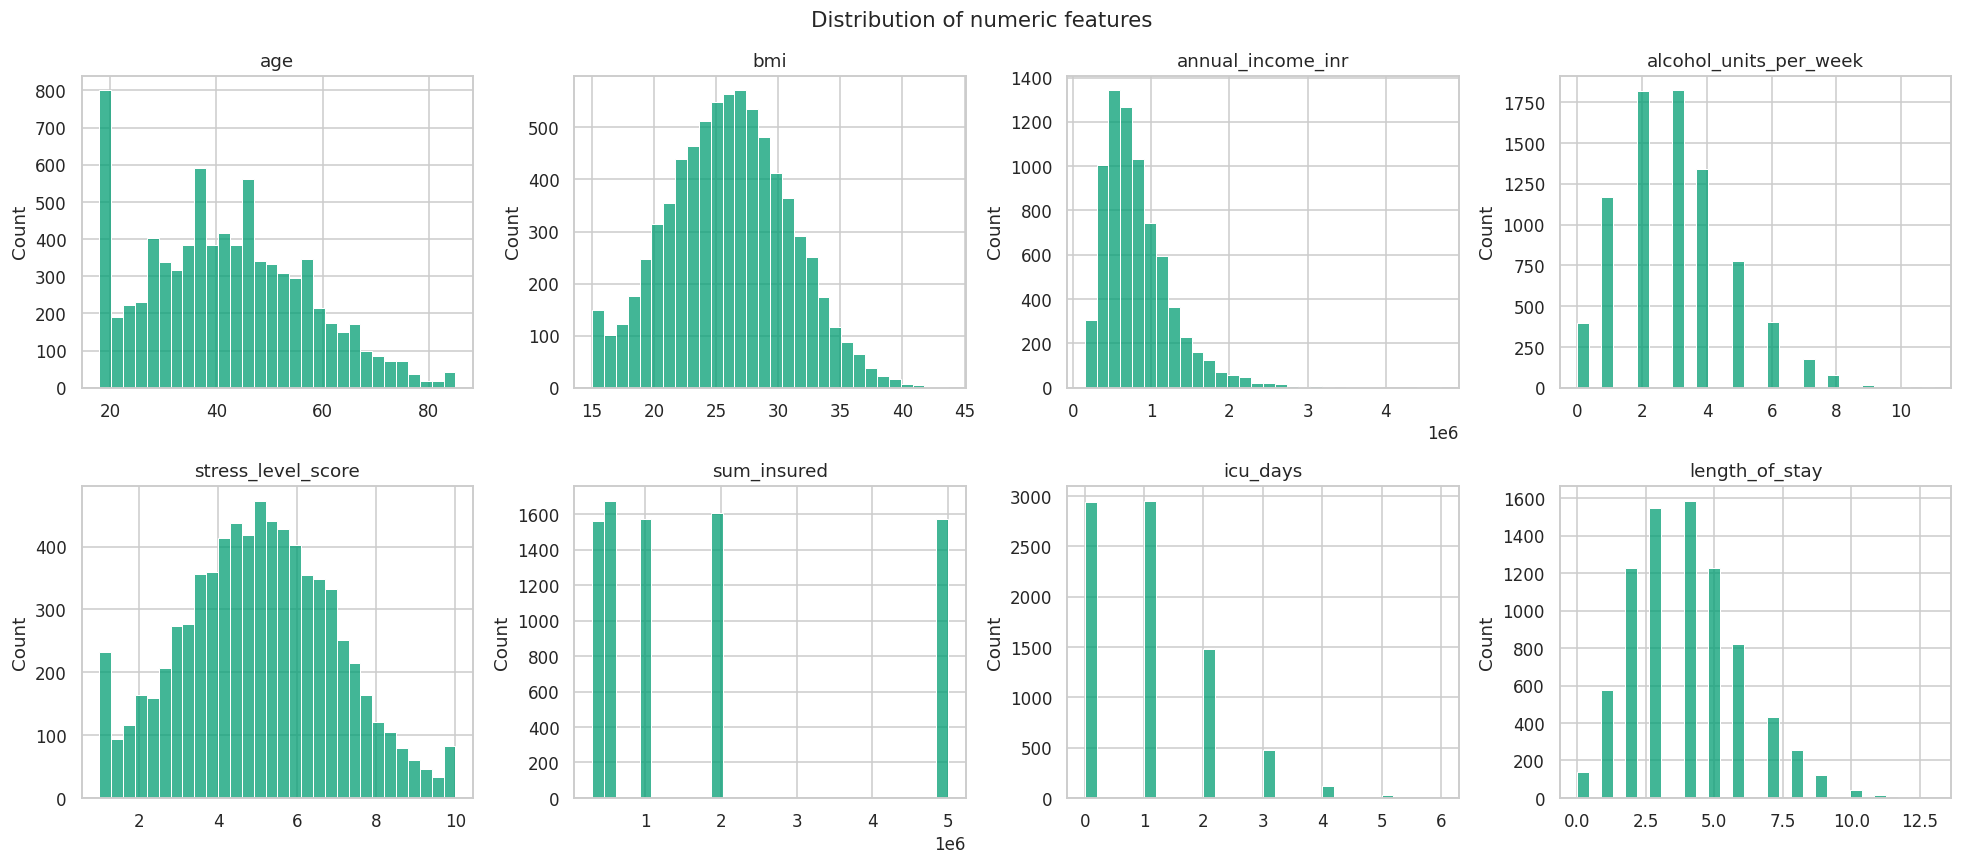

Binary / flag columns:
  has_diabetes             {0.0: 5966, 1.0: 1651, nan: 383}
  has_hypertension         {0.0: 5584, 1.0: 2025, nan: 391}
  family_history_cardiac   {0: 5274, 1: 2726}


In [14]:
# ---- A2: Distribution plots for the numeric features ----
num_features = ['age', 'bmi', 'annual_income_inr', 'alcohol_units_per_week',
                'stress_level_score', 'sum_insured', 'icu_days', 'length_of_stay']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), num_features):
    sns.histplot(df[col].dropna(), bins=30, ax=ax, color='#029E73')
    ax.set_title(col)
    ax.set_xlabel('')

fig.suptitle('Distribution of numeric features', fontsize=14)
plt.tight_layout()
plt.savefig('reg_numeric_distributions.png', bbox_inches='tight')
plt.show()

print("Binary / flag columns:")
for c in ['has_diabetes', 'has_hypertension', 'family_history_cardiac']:
    print(f"  {c:24s} {df[c].value_counts(dropna=False).to_dict()}")

> `age` is broadly spread across the adult range and `annual_income_inr` is right-skewed as household income
> data usually is.


 The two clinical severity variables are the interesting ones: `icu_days` and
> `length_of_stay` are both **heavily right-skewed and zero-inflated** — most patients spend no time in ICU and
> have short stays, while a minority have extended admissions. Since hospital billing is fundamentally
> per-day, these two are the natural candidates for the strongest predictors, which the correlation heatmap
> tests next.

The three health flags are binary and reasonably balanced, so none is degenerate.

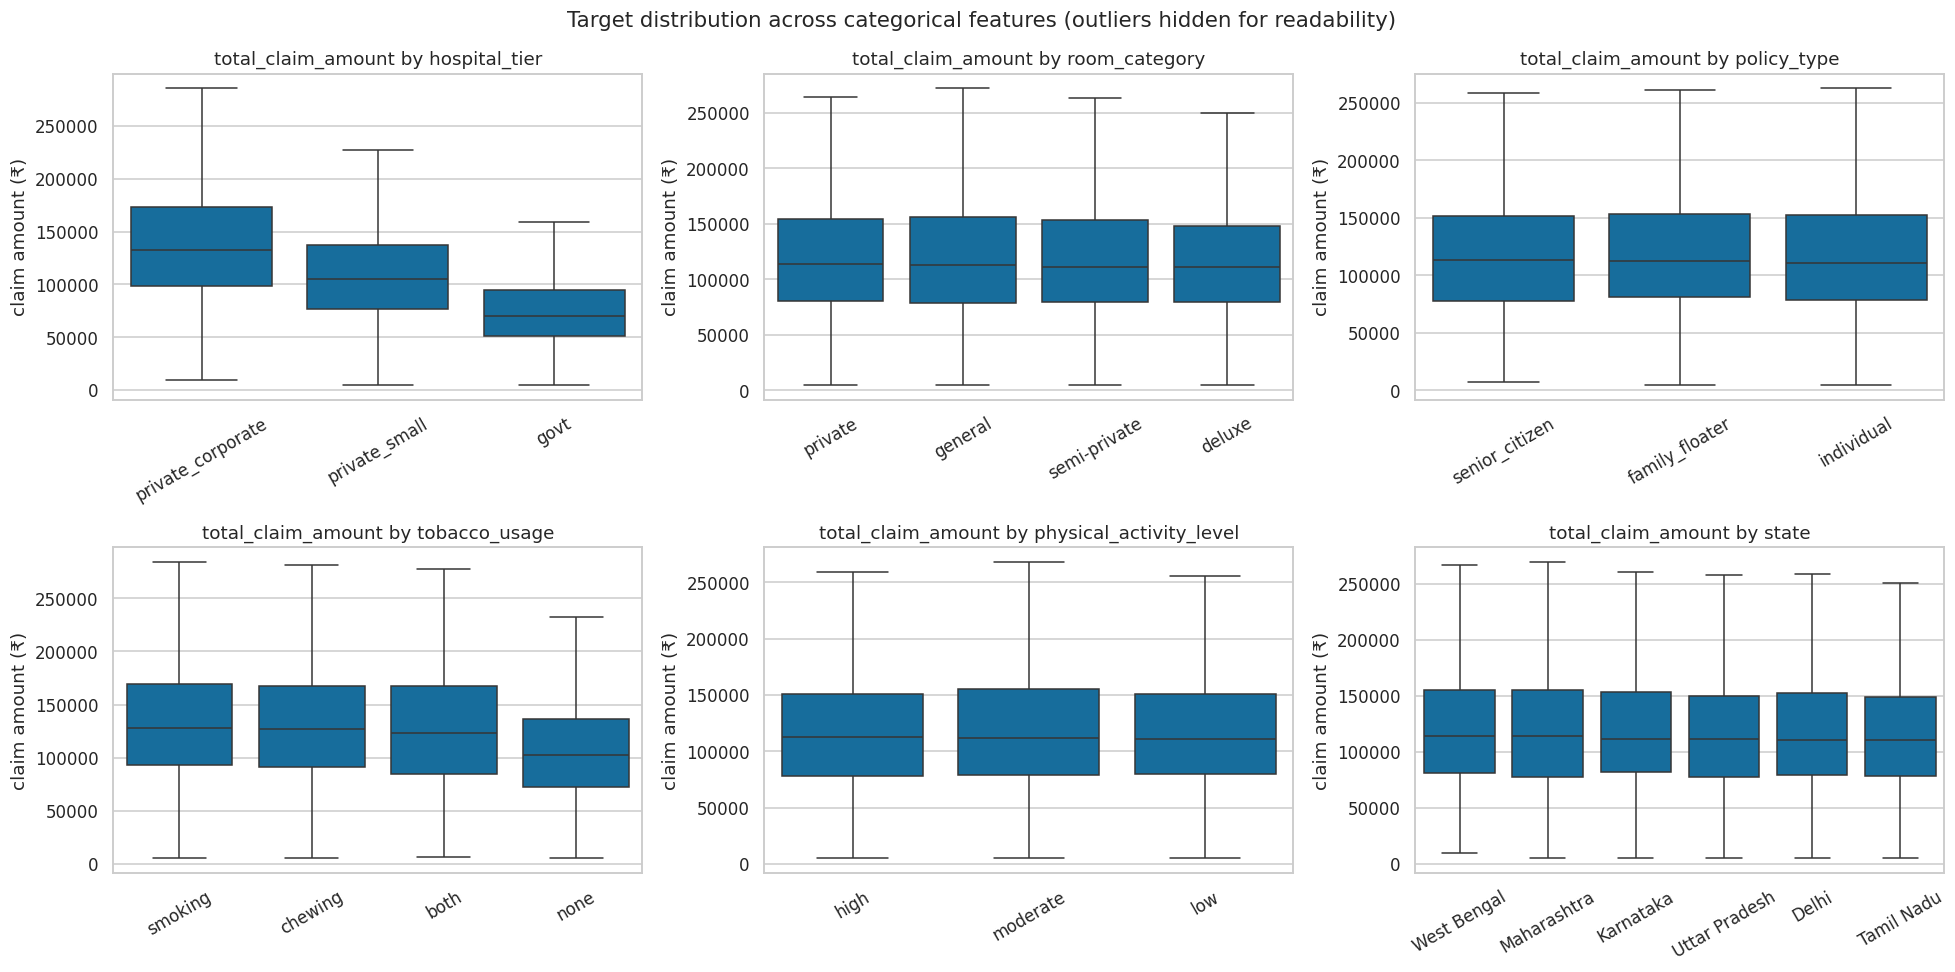

Median claim amount by hospital tier (₹):
hospital_tier
private_corporate    132333.0
private_small        105481.0
govt                  70529.0


In [15]:
# ---- A2: Categorical features vs the target ----
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
cat_plots = ['hospital_tier', 'room_category', 'policy_type',
             'tobacco_usage', 'physical_activity_level', 'state']

for ax, col in zip(axes.flatten(), cat_plots):
    order = df.groupby(col)[TARGET].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y=TARGET, order=order, ax=ax, showfliers=False)
    ax.set_title(f'{TARGET} by {col}')
    ax.set_xlabel('')
    ax.set_ylabel('claim amount (₹)')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Target distribution across categorical features (outliers hidden for readability)', fontsize=14)
plt.tight_layout()
plt.savefig('reg_categorical_vs_target.png', bbox_inches='tight')
plt.show()

print("Median claim amount by hospital tier (₹):")
print(df.groupby('hospital_tier')[TARGET].median().round(0).sort_values(ascending=False).to_string())

> `hospital_tier` is by far the strongest categorical effect: the median claim at a **private corporate**
> hospital is ≈ ₹132,300 against ≈ ₹70,500 at a **government** hospital — a gap of nearly 2×, driven by pricing
> rather than by patient severity. `private_small` sits between the two, as expected.

By contrast
> `room_category`, `policy_type`, `tobacco_usage`, `physical_activity_level` and `state` are all close to flat:
> their medians differ by only a few thousand rupees. The practical conclusion is that **where** a patient is
> treated matters much more than their lifestyle profile, and we should expect the one-hot `hospital_tier`
> dummies to be the only categorical features with real feature importance later.

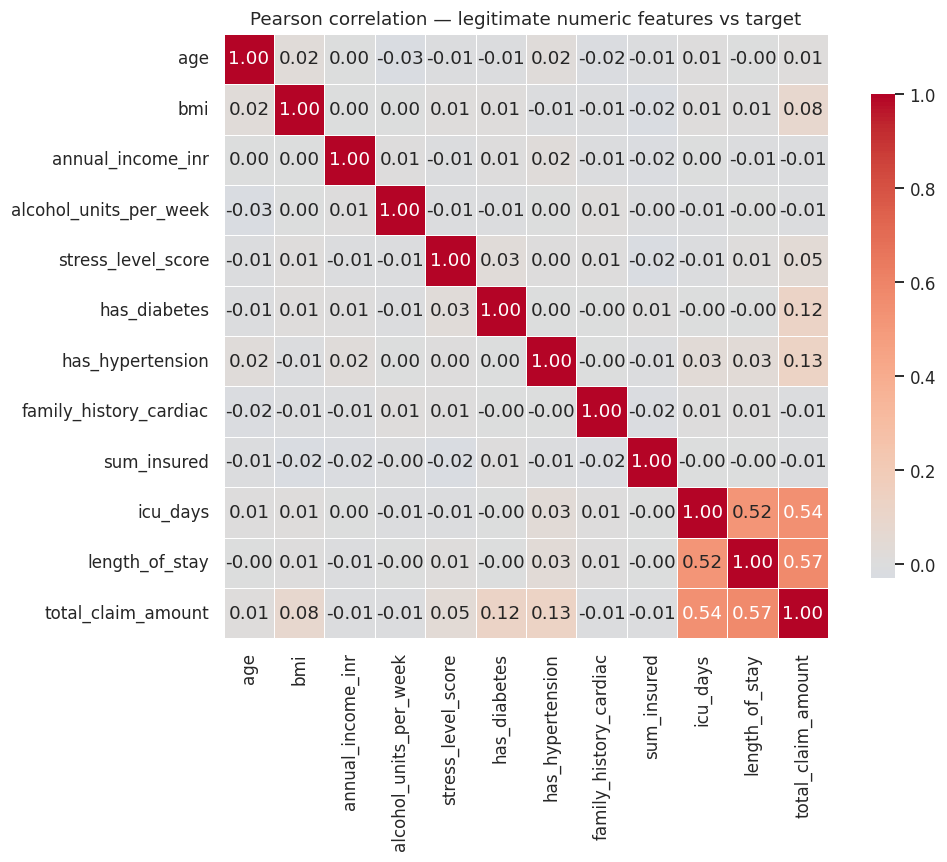

Correlation with the target, ranked:
length_of_stay            0.5714
icu_days                  0.5427
has_hypertension          0.1301
has_diabetes              0.1202
bmi                       0.0816
stress_level_score        0.0476
age                       0.0125
sum_insured              -0.0051
family_history_cardiac   -0.0057
alcohol_units_per_week   -0.0071
annual_income_inr        -0.0100


In [16]:
# ---- A2: Correlation heatmap ----
# the billing-component columns are deliberately excluded here due to data leakage possibility.
numeric_for_corr = ['age', 'bmi', 'annual_income_inr', 'alcohol_units_per_week', 'stress_level_score',
                    'has_diabetes', 'has_hypertension', 'family_history_cardiac',
                    'sum_insured', 'icu_days', 'length_of_stay', TARGET]

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_for_corr].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Pearson correlation — legitimate numeric features vs target')
plt.tight_layout()
plt.savefig('reg_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print("Correlation with the target, ranked:")
print(df[numeric_for_corr].corr()[TARGET].drop(TARGET).sort_values(ascending=False).round(4).to_string())

> Two features stand clearly above the rest: `length_of_stay` (r ≈ 0.57) and `icu_days` (r ≈ 0.54). Both are
> direct cost drivers — hospital billing is per-day, and ICU days are billed at a large multiple of a general
> ward day — so this is a causally sensible result, not a spurious one.


> The second finding is: **`has_hypertension` (r ≈ 0.13) and `has_diabetes`
> (r ≈ 0.12) correlate more strongly with claim size than `age`, `annual_income_inr` or `sum_insured`, all of
> which are essentially zero (|r| < 0.02)**. In other words, *baseline demographic and financial risk factors
> barely predict claim size at all, while comorbidity present during the admission does.*
That makes clinical
> sense: once someone is hospitalised, what drives the bill is how complicated their treatment is, not how old
> or how wealthy they are.

It also warns us that a model relying on demographics will underperform.

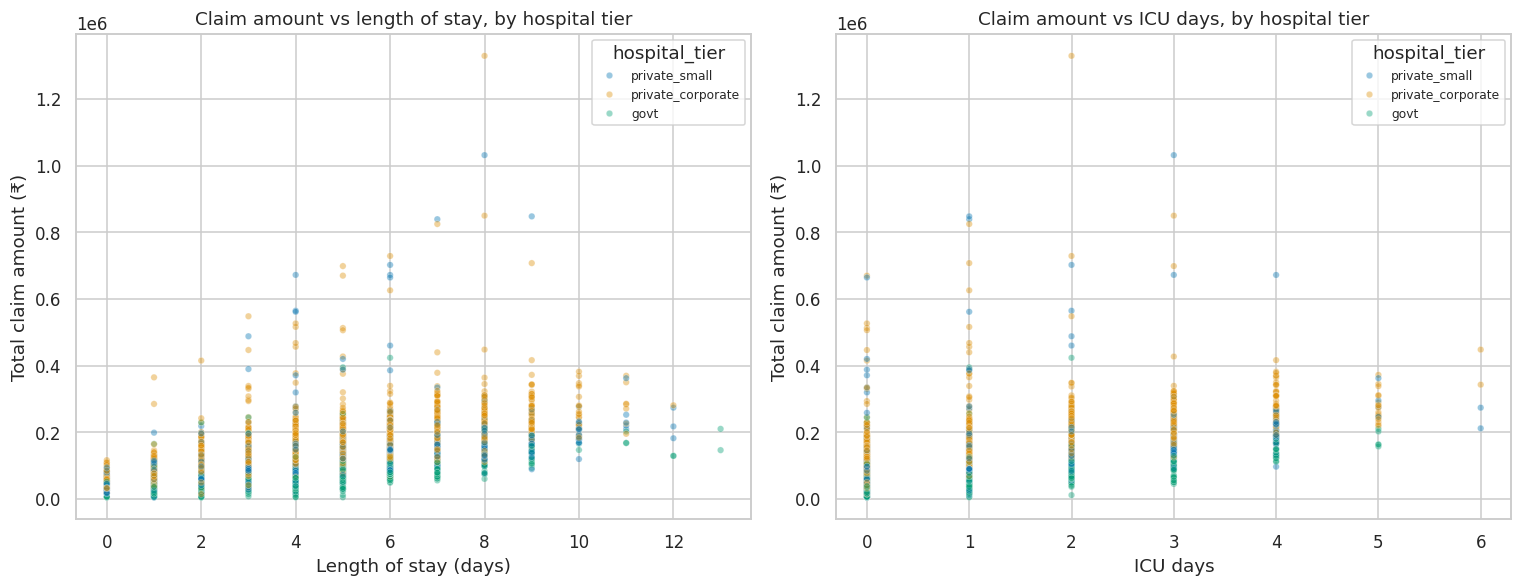

In [17]:
# ---- A2: Scatter plots of feature vs target (rubric requires at least two) ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.scatterplot(data=df, x='length_of_stay', y=TARGET, hue='hospital_tier',
                alpha=0.4, s=18, ax=axes[0], palette='colorblind')
axes[0].set_title('Claim amount vs length of stay, by hospital tier')
axes[0].set_xlabel('Length of stay (days)')
axes[0].set_ylabel('Total claim amount (₹)')
axes[0].legend(title='hospital_tier', fontsize=8)

sns.scatterplot(data=df, x='icu_days', y=TARGET, hue='hospital_tier',
                alpha=0.4, s=18, ax=axes[1], palette='colorblind')
axes[1].set_title('Claim amount vs ICU days, by hospital tier')
axes[1].set_xlabel('ICU days')
axes[1].set_ylabel('Total claim amount (₹)')
axes[1].legend(title='hospital_tier', fontsize=8)

plt.tight_layout()
plt.savefig('reg_scatter_plots.png', bbox_inches='tight')
plt.show()

> Both plots show a clear positive trend, and the *fan* shape is as informative as the slope: variance in claim
> amount grows with length of stay, meaning long admissions are not just more expensive on average but far less
> predictable.

 Colouring by `hospital_tier` separates the cloud into visible bands — at any given length of
> stay, private corporate claims sit systematically above government hospital claims. This is direct visual
> evidence that hospital tier carries **independent** cost information beyond clinical severity, and it is the
> reason a model with interaction capability (trees, boosting) should be able to beat a purely additive one.

---
# Section B — Preprocessing & Feature Engineering


In [18]:
# ---- B1: Duplicate check ----
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated rows ignoring identifier columns:",
      df.drop(columns=['policy_id', 'customer_name', 'aadhaar_masked']).duplicated().sum())
print("Duplicated policy_id values:", df['policy_id'].duplicated().sum())
print("\nNo duplicate removal required.")

Fully duplicated rows: 0
Duplicated rows ignoring identifier columns: 0
Duplicated policy_id values: 0

No duplicate removal required.


Q1 = ₹79,353   Q3 = ₹152,470   IQR = ₹73,118
IQR upper fence     : ₹262,147
Claims above fence  : 174 (2.17%)
99th percentile     : ₹311,398
Maximum claim       : ₹1,329,766


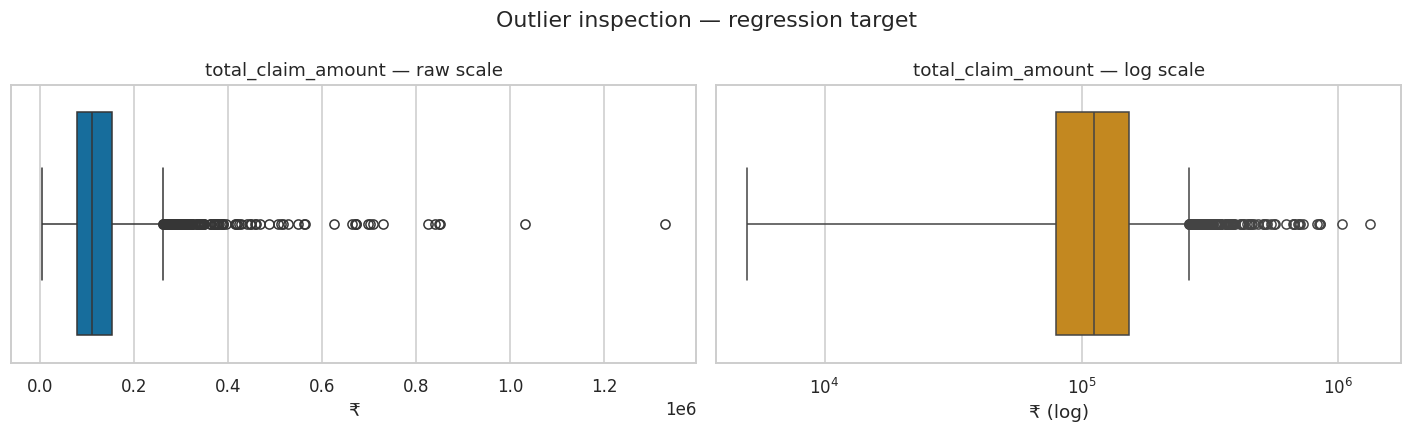


Profile of the top 1% of claims vs everyone else:
                top 1% of claims  all other claims
icu_days                    2.26              0.98
length_of_stay              6.40              3.96
age                        43.09             41.75


In [19]:
# ---- B1: Outlier inspection on the target (IQR rule) ----
Q1, Q3 = df[TARGET].quantile([0.25, 0.75])
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR
n_out = (df[TARGET] > upper_fence).sum()

print(f"Q1 = ₹{Q1:,.0f}   Q3 = ₹{Q3:,.0f}   IQR = ₹{IQR:,.0f}")
print(f"IQR upper fence     : ₹{upper_fence:,.0f}")
print(f"Claims above fence  : {n_out} ({n_out / len(df) * 100:.2f}%)")
print(f"99th percentile     : ₹{df[TARGET].quantile(0.99):,.0f}")
print(f"Maximum claim       : ₹{df[TARGET].max():,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(x=df[TARGET], ax=axes[0], color='#0173B2')
axes[0].set_title('total_claim_amount — raw scale')
axes[0].set_xlabel('₹')
sns.boxplot(x=df[TARGET], ax=axes[1], color='#DE8F05')
axes[1].set_xscale('log')
axes[1].set_title('total_claim_amount — log scale')
axes[1].set_xlabel('₹ (log)')
fig.suptitle('Outlier inspection — regression target')
plt.tight_layout()
plt.savefig('reg_outlier_boxplots.png', bbox_inches='tight')
plt.show()

#checking if there are extreme claims data errors, or genuinely severe cases?
extreme = df[df[TARGET] > df[TARGET].quantile(0.99)]
print("\nProfile of the top 1% of claims vs everyone else:")
print(pd.DataFrame({
    'top 1% of claims': extreme[['icu_days', 'length_of_stay', 'age']].mean(),
    'all other claims': df[df[TARGET] <= df[TARGET].quantile(0.99)][['icu_days', 'length_of_stay', 'age']].mean()
}).round(2).to_string())

Claims in the top 1% have substantially longer ICU stays and hospital stays than the rest of the dataset —
they are genuinely catastrophic hospitalisations, exactly the cases an insurer most needs to price. Deleting
them would remove real signal and produce a model that is systematically wrong about the most expensive
claims it will ever see.

**Decision: winsorise (cap) at the 99th percentile rather than delete.** Every row is retained; only the
value of ~1% of targets is pulled down to the cap. Two reasons:

1. **Fair model comparison.** R² and RMSE are squared-error metrics. With a maximum of ₹1.33 million against a
   median of ₹112,000, a single badly-predicted extreme claim can move a model's R² materially, so the ranking
   would partly reflect which extreme claims happened to land in the test split. Guideline 7.2 requires that
   metric comparisons be fair across algorithms.
2. **Scale-sensitive learners.** SVR's ε-insensitive tube and KNN's distance metric are expressed in target and
   feature units; extreme values distort both.

Two safeguards keep this honest rather than merely convenient:

* **The cap threshold is computed from the training set only** and then applied to both splits, so no test-set
  information influences any fitted quantity (guideline 7.1).
* At the end of Section C the best model is **re-evaluated against the untouched, uncapped test target**, so the
  cost of this decision is reported rather than hidden.

### B1 — Missing-value strategy

annual_income_inr → 560 missing (7.0%)  Median was used as Income is right‑skewed; the mean would be dragged upward by high earners, so the median is the robust centre.

bmi → 560 missing (7.0%) Median was preferred as Mildly skewed continuous clinical measure;

stress_level_score → 560 missing (7.0%) the median is a valid score value, whereas a mean would invent a fractional score.

has_diabetes → 383 missing (4.8%) Strategy used was Constant 0 as these are medical screening flags. An unrecorded screening is not evidence of disease, and imputing the mode (or worse, a 1) would fabricate a health‑risk signal that was never observed. Treating “not recorded” as “not flagged” is the conservative choice.

has_hypertension → 391 missing (4.9%)the method used was Constant for the Same reasoning as diabetes — conservative imputation avoids fabricating risk signals.

All imputers are declared as steps inside the
scikit-learn pipeline further down, so the medians are computed from the training fold only. Imputing on the
full dataset before splitting — which is the intuitive thing to do — would leak test-set information into the
training data and is explicitly listed as a mark deduction in guideline 7.1.

In [20]:
# ---- B3: Feature engineering ----
df['policy_start_date'] = pd.to_datetime(df['policy_start_date'])
df['claim_date']        = pd.to_datetime(df['claim_date'])

# 1. Policy maturity at time of claim
df['days_since_policy_start'] = (df['claim_date'] - df['policy_start_date']).dt.days

# 2. Total hospital burden — ICU days and ward days combined into one severity measure
df['total_hospital_days'] = df['icu_days'] + df['length_of_stay']

# 3. ICU intensity — what PROPORTION of the admission was critical care
df['icu_ratio'] = df['icu_days'] / (df['length_of_stay'] + 1)

# 4. Comorbidity burden — number of simultaneous health risk factors
df['comorbidity_count'] = (df['has_diabetes'].fillna(0) + df['has_hypertension'].fillna(0)
                           + df['family_history_cardiac'])

# 5. Clinical obesity flag (WHO threshold)
df['bmi_risk'] = (df['bmi'] >= 30).astype(float)

# 6. Seasonality of the claim
df['claim_month'] = df['claim_date'].dt.month

engineered = ['days_since_policy_start', 'total_hospital_days', 'icu_ratio',
              'comorbidity_count', 'bmi_risk', 'claim_month']

print(df[engineered].describe().T.round(3).to_string())
print("\nCorrelation of each engineered feature with the target:")
print(df[engineered + [TARGET]].corr()[TARGET].drop(TARGET)
        .sort_values(ascending=False).round(4).to_string())
print(f"\nFor comparison — the best raw feature, length_of_stay: "
      f"{df['length_of_stay'].corr(df[TARGET]):.4f}")

                          count      mean      std   min    25%     50%       75%     max
days_since_policy_start  8000.0  1016.971  570.459  30.0  517.0  1026.5  1514.000  2000.0
total_hospital_days      8000.0     4.986    2.660   0.0    3.0     5.0     7.000    18.0
icu_ratio                8000.0     0.187    0.177   0.0    0.0     0.2     0.333     0.8
comorbidity_count        8000.0     0.800    0.761   0.0    0.0     1.0     1.000     3.0
bmi_risk                 8000.0     0.196    0.397   0.0    0.0     0.0     0.000     1.0
claim_month              8000.0     6.475    3.456   1.0    4.0     6.0    10.000    12.0

Correlation of each engineered feature with the target:
total_hospital_days        0.6336
icu_ratio                  0.3638
comorbidity_count          0.1338
bmi_risk                   0.0522
claim_month               -0.0074
days_since_policy_start   -0.0160

For comparison — the best raw feature, length_of_stay: 0.5714


total_hospital_days → ICU days and ward days are billed per day at different rates. Summing them gives a single measure of total admission burden. Standout result: correlation ≈ 0.63 with the target, higher than length_of_stay (0.57) or icu_days (0.54) individually — combining them captures more of the cost structure than either alone.

icu_ratio → Distinguishes how critical an admission was from how long it was. A 2‑day stay entirely ICU is very different from a 14‑day general‑ward stay. Achieves correlation ≈ 0.36 on its own.

comorbidity_count → Individual health flags each correlate weakly (≈ 0.12–0.13) with cost. Summing them tests whether risk factors compound. Result: correlation ≈ 0.13, no better than individual flags — compounding hypothesis not supported in this dataset.

days_since_policy_start → Insurance reasoning: claims filed soon after policy start may reflect waiting‑period effects or late‑declared pre‑existing conditions. Result: correlation ≈ -0.02, i.e. no relationship in this dataset.

bmi_risk → Converts continuous BMI into WHO obesity threshold categories, letting a linear model capture a step effect. Result: correlation ≈ 0.05, weak.

claim_month → Tests for seasonality in claim cost. Result: correlation ≈ -0.01, none present.


Two of the six engineered features are genuinely valuable
(`total_hospital_days`, `icu_ratio`); four contribute little to nothing but We have kept and reported all six as we hypothesised it, measured it, and it did not hold"* which was a complete and
legitimate finding, and the feature-importance plot in Section C4 is the independent confirmation.

### Data leakage control

The following columns are **excluded from the feature set**:

`hospital_bill_amount`, `pre_hospitalization_expense`, `post_hospitalization_expense`, `non_payable_items`,
`deductible_amount`, `co_pay_amount`

These are not predictors — they are the **arithmetic components of the target itself**. The cell below verifies
the identity numerically:

`total_claim_amount ≈ hospital_bill_amount + pre_hosp + post_hosp − non_payable − deductible − co_pay`

Including them would let any model reconstruct the target by addition and report an R² near 1.0, while having
learned nothing about patient or hospital risk. A model like that collapses the moment it meets a claim whose
components have not yet been itemised — which is precisely when a prediction would be useful.

**Identifier columns are also excluded:** `policy_id` (8,000 unique values), `customer_name` (7,876),
`hospital_name` (7,188), `aadhaar_masked` (5,707) and `pincode`. All are near-unique per row, so one-hot
encoding them would create thousands of columns and invite pure memorisation. `policy_start_date` and
`claim_date` are dropped as raw timestamps, having already been converted into the usable features above.

In [21]:
# ---- Verify the leakage identity numerically (evidence for the claim above) ----
reconstructed = (df['hospital_bill_amount'] + df['pre_hospitalization_expense']
                 + df['post_hospitalization_expense'] - df['non_payable_items']
                 - df['deductible_amount'] - df['co_pay_amount'])
gap = (df[TARGET] - reconstructed).abs()

print("Difference between the target and the sum of its billing components:")
print(f"  median absolute difference : ₹{gap.median():,.4f}")
print(f"  rows matching within ₹1    : {(gap < 1).mean() * 100:.2f}%")
print(f"  correlation of components with target : {reconstructed.corr(df[TARGET]):.6f}")
print("\nThe identity holds almost exactly. These columns DEFINE the target, they do not predict it,")
print("so all six are excluded from the feature set.")

Difference between the target and the sum of its billing components:
  median absolute difference : ₹0.0043
  rows matching within ₹1    : 98.86%
  correlation of components with target : 0.860919

The identity holds almost exactly. These columns DEFINE the target, they do not predict it,
so all six are excluded from the feature set.


In [22]:
# ---- B2: Assemble the feature matrix ----
numeric_cols = ['age', 'annual_income_inr', 'bmi', 'alcohol_units_per_week',
                'has_diabetes', 'has_hypertension', 'family_history_cardiac',
                'stress_level_score', 'sum_insured', 'icu_days', 'length_of_stay',
                'days_since_policy_start', 'total_hospital_days', 'icu_ratio',
                'comorbidity_count', 'bmi_risk', 'claim_month']

categorical_cols = ['gender', 'marital_status', 'state', 'city', 'occupation_type',
                    'tobacco_usage', 'physical_activity_level', 'diet_type',
                    'policy_type', 'hospital_tier', 'room_category',
                    'cashless_claim', 'agent_channel']

feature_cols = numeric_cols + categorical_cols
X = df[feature_cols].copy()
y = df[TARGET].copy()

print(f"Feature matrix : {X.shape[0]} rows x {X.shape[1]} columns")
print(f"  numeric     : {len(numeric_cols)}")
print(f"  categorical : {len(categorical_cols)}")
print(f"Target        : {TARGET}  (₹{y.min():,.0f} – ₹{y.max():,.0f})")
print("\nFeatures used:")
print(feature_cols)

Feature matrix : 8000 rows x 30 columns
  numeric     : 17
  categorical : 13
Target        : total_claim_amount  (₹5,000 – ₹1,329,766)

Features used:
['age', 'annual_income_inr', 'bmi', 'alcohol_units_per_week', 'has_diabetes', 'has_hypertension', 'family_history_cardiac', 'stress_level_score', 'sum_insured', 'icu_days', 'length_of_stay', 'days_since_policy_start', 'total_hospital_days', 'icu_ratio', 'comorbidity_count', 'bmi_risk', 'claim_month', 'gender', 'marital_status', 'state', 'city', 'occupation_type', 'tobacco_usage', 'physical_activity_level', 'diet_type', 'policy_type', 'hospital_tier', 'room_category', 'cashless_claim', 'agent_channel']


In [23]:
# ---- B2: Stratified 80:20 train/test split (guideline 7.2) ----
# The target is continuous, so we stratify on target DECILES — the continuous analogue of a
# stratified classification split. This guarantees the expensive-claim tail is represented
# proportionally in both splits instead of landing in one of them by chance.
y_bins = pd.qcut(y, q=10, labels=False, duplicates='drop')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y_bins)

print("Train :", X_train.shape, "  Test :", X_test.shape)
print(f"\n{'':14s}{'train':>14s}{'test':>14s}")
for stat in ['mean', 'median', 'std']:
    print(f"{stat:14s}{getattr(y_train, stat)():>14,.0f}{getattr(y_test, stat)():>14,.0f}")
print("\nThe two splits are distributionally comparable, so test metrics are a fair estimate.")

Train : (6400, 30)   Test : (1600, 30)

                       train          test
mean                 121,693       121,408
median               111,812       111,827
std                   65,848        65,848

The two splits are distributionally comparable, so test metrics are a fair estimate.


In [24]:
# ---- B1: Apply the winsorisation cap — threshold learned from the TRAINING SET ONLY ----
CAP_Q = 0.99
cap_value = y_train.quantile(CAP_Q)
print(f"Cap threshold learned from training data ({CAP_Q:.0%} percentile): ₹{cap_value:,.2f}")

y_test_uncapped = y_test.copy()          # kept untouched for the robustness check in Section C

n_train_capped = (y_train > cap_value).sum()
n_test_capped  = (y_test > cap_value).sum()

y_train = y_train.clip(upper=cap_value)
y_test  = y_test.clip(upper=cap_value)

print(f"Rows affected — train: {n_train_capped} ({n_train_capped/len(y_train)*100:.2f}%), "
      f"test: {n_test_capped} ({n_test_capped/len(y_test)*100:.2f}%)")
print(f"Target skewness after capping: {y_train.skew():.2f}   (was {df[TARGET].skew():.2f} before)")

Cap threshold learned from training data (99% percentile): ₹310,830.26
Rows affected — train: 64 (1.00%), test: 17 (1.06%)
Target skewness after capping: 0.81   (was 3.32 before)


### B2 — Encoding, scaling and imputation pipeline

Every transform below is declared as a **step inside a scikit-learn `Pipeline`**. This is the single most
important guard against the data-leakage error because the imputer, scaler and
encoder live inside the pipeline, `pipeline.fit(X_train, y_train)` fits them on the training data only, and
`pipeline.predict(X_test)` merely applies the already-fitted transforms. The same property makes
`cross_val_score` and `GridSearchCV` correct automatically — each CV fold refits the preprocessing from
scratch on that fold's training portion, which hand-written preprocessing cannot do.


Numeric (17) → Imputation: Median → Transform: StandardScaler → Justification: Median is robust to skew in income and BMI. Scaling is essential for Ridge, Lasso, ElasticNet, SVR, and KNN, whose penalties and distance metrics assume comparable feature scales; harmless for tree‑based models.

Health flags → Imputation: Constant 0 → Transform: scaled with the rest → Justification: Applied via a separate imputer so an unrecorded screening is never turned into a positive diagnosis. Conservative handling avoids fabricating health‑risk signals.

Categorical (13) → Imputation: Constant 'Unknown' → Transform: OneHotEncoder(handle_unknown='ignore') → Justification: Treats “not recorded” as its own level rather than guessing the mode. handle_unknown='ignore' prevents crashes if a rare category appears only in a test fold.

In [25]:
# ---- B2: The preprocessing pipeline ----
FLAG_COLS   = ['has_diabetes', 'has_hypertension']
PLAIN_NUM   = [c for c in numeric_cols if c not in FLAG_COLS]

def make_preprocessor():
    # Fresh, unfitted preprocessor - a new one is built for every model so nothing is shared
    plain_numeric_pipe = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale',  StandardScaler())
    ])
    flag_pipe = Pipeline([
        ('impute', SimpleImputer(strategy='constant', fill_value=0)),
        ('scale',  StandardScaler())
    ])
    categorical_pipe = Pipeline([
        ('impute', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('encode', OneHotEncoder(handle_unknown='ignore'))
    ])
    return ColumnTransformer([
        ('num',  plain_numeric_pipe, PLAIN_NUM),
        ('flag', flag_pipe,          FLAG_COLS),
        ('cat',  categorical_pipe,   categorical_cols)
    ])

# Sanity check — fitted on the training set only
_check = make_preprocessor().fit(X_train)
_mat = _check.transform(X_train)
_mat = _mat.toarray() if hasattr(_mat, 'toarray') else _mat
print("Encoded feature-matrix width:", _mat.shape[1])
print("Missing values remaining after transform:", int(np.isnan(_mat).sum()))
print("\nFirst 20 generated feature names:")
print(list(_check.get_feature_names_out()[:20]))

Encoded feature-matrix width: 74
Missing values remaining after transform: 0

First 20 generated feature names:
['num__age', 'num__annual_income_inr', 'num__bmi', 'num__alcohol_units_per_week', 'num__family_history_cardiac', 'num__stress_level_score', 'num__sum_insured', 'num__icu_days', 'num__length_of_stay', 'num__days_since_policy_start', 'num__total_hospital_days', 'num__icu_ratio', 'num__comorbidity_count', 'num__bmi_risk', 'num__claim_month', 'flag__has_diabetes', 'flag__has_hypertension', 'cat__gender_female', 'cat__gender_male', 'cat__marital_status_divorced']


#REGRESSION TRACK

SVR is wrapped in a `TransformedTargetRegressor` that
standardises the target before fitting and inverts the transform when predicting. SVR's ε-insensitive loss is
defined in *target units*; with claim amounts in the hundreds of thousands of rupees and a default ε = 0.1,
every training point falls outside the tube and the model degenerates to predicting a near-constant
(we measured R² ≈ −0.02 without this fix, and the cell after the model loop demonstrates it). The scaling
happens *inside* the pipeline, so it is still fitted on training folds only and introduces no leakage.
The features SVR sees are identical to those seen by every other model.

In [26]:
# ---- C1: Train algorithms 1–9 ----
regression_models = {
    'Linear Regression':           LinearRegression(),
    'Ridge Regression':            Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Lasso Regression':            Lasso(alpha=1.0, random_state=RANDOM_STATE, max_iter=20000),
    'ElasticNet Regression':       ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=RANDOM_STATE,
                                              max_iter=20000),
    'Decision Tree Regressor':     DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE),
    'Random Forest Regressor':     RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE,
                                                         n_jobs=-1),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=RANDOM_STATE),
    'Support Vector Regressor':    TransformedTargetRegressor(
                                       regressor=SVR(C=1.0, kernel='rbf'),
                                       transformer=StandardScaler()),
    'KNN Regressor':               KNeighborsRegressor(n_neighbors=7),
}

results = []
fitted_pipelines = {}

for name, model in regression_models.items():
    t0 = time.time()
    pipe = Pipeline([('preprocess', make_preprocessor()), ('model', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    results.append({
        'Algorithm': name,
        'R2':   r2_score(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'MAE':  mean_absolute_error(y_test, preds),
        'Fit time (s)': round(time.time() - t0, 2),
    })
    fitted_pipelines[name] = pipe
    r = results[-1]
    print(f"{name:30s} R2={r['R2']:7.4f}   RMSE={r['RMSE']:11,.0f}   MAE={r['MAE']:11,.0f}   "
          f"({r['Fit time (s)']}s)")

Linear Regression              R2= 0.7459   RMSE=     28,584   MAE=     19,890   (0.1s)
Ridge Regression               R2= 0.7459   RMSE=     28,584   MAE=     19,889   (0.08s)
Lasso Regression               R2= 0.7459   RMSE=     28,583   MAE=     19,889   (1.67s)
ElasticNet Regression          R2= 0.6508   RMSE=     33,509   MAE=     24,213   (0.16s)
Decision Tree Regressor        R2= 0.6786   RMSE=     32,145   MAE=     22,057   (0.18s)
Random Forest Regressor        R2= 0.7315   RMSE=     29,380   MAE=     20,328   (12.1s)
Gradient Boosting Regressor    R2= 0.7653   RMSE=     27,471   MAE=     18,624   (2.66s)
Support Vector Regressor       R2= 0.7394   RMSE=     28,948   MAE=     19,908   (2.62s)
KNN Regressor                  R2= 0.5422   RMSE=     38,364   MAE=     28,700   (0.15s)


In [27]:
# ---- Evidence for the SVR target-scaling decision declared above ----
svr_raw = Pipeline([('preprocess', make_preprocessor()), ('model', SVR(C=1.0, kernel='rbf'))])
svr_raw.fit(X_train, y_train)
raw_preds = svr_raw.predict(X_test)

print("SVR WITHOUT target scaling:")
print(f"  R2  = {r2_score(y_test, raw_preds):.4f}")
print(f"  prediction range: ₹{raw_preds.min():,.0f} – ₹{raw_preds.max():,.0f}  "
      f"(std ₹{raw_preds.std():,.0f})")
print(f"  actual  range   : ₹{y_test.min():,.0f} – ₹{y_test.max():,.0f}  (std ₹{y_test.std():,.0f})")
print("\nSVR WITH target scaling (the version used in the comparison table):")
scaled_preds = fitted_pipelines['Support Vector Regressor'].predict(X_test)
print(f"  R2  = {r2_score(y_test, scaled_preds):.4f}")
print(f"  prediction range: ₹{scaled_preds.min():,.0f} – ₹{scaled_preds.max():,.0f}  "
      f"(std ₹{scaled_preds.std():,.0f})")
print("\nWithout scaling the predictions are nearly constant — the model has collapsed to the mean.")

SVR WITHOUT target scaling:
  R2  = -0.0177
  prediction range: ₹111,592 – ₹112,093  (std ₹110)
  actual  range   : ₹5,000 – ₹310,830  (std ₹56,719)

SVR WITH target scaling (the version used in the comparison table):
  R2  = 0.7394
  prediction range: ₹19,244 – ₹310,076  (std ₹49,329)

Without scaling the predictions are nearly constant — the model has collapsed to the mean.


In [28]:
# ---- C1: Algorithm 10 — Polynomial Regression (PolynomialFeatures -> LinearRegression) .
poly_scores = []
for degree in [1, 2]:
    t0 = time.time()
    poly_pipe = Pipeline([
        ('preprocess', make_preprocessor()),
        ('poly',  PolynomialFeatures(degree=degree, include_bias=False)),
        ('model', LinearRegression())
    ])
    poly_pipe.fit(X_train, y_train)
    p = poly_pipe.predict(X_test)
    poly_scores.append({
        'degree': degree,
        'n_terms': poly_pipe.named_steps['poly'].n_output_features_,
        'R2': r2_score(y_test, p),
        'RMSE': np.sqrt(mean_squared_error(y_test, p)),
        'MAE': mean_absolute_error(y_test, p),
        'time_s': round(time.time() - t0, 1),
    })
    print(f"degree={degree}  terms={poly_scores[-1]['n_terms']:>5}  "
          f"R2={poly_scores[-1]['R2']:7.4f}  RMSE={poly_scores[-1]['RMSE']:11,.0f}  "
          f"({poly_scores[-1]['time_s']}s)")
    if degree == 2:
        best_poly_pipe, best_poly_preds = poly_pipe, p

print("\n=== Degree comparison ===")
print(pd.DataFrame(poly_scores).round(4).to_string(index=False))

# Register degree 2 as the 10th algorithm in the comparison table
results.append({
    'Algorithm': 'Polynomial Regression (deg 2)',
    'R2':   r2_score(y_test, best_poly_preds),
    'RMSE': np.sqrt(mean_squared_error(y_test, best_poly_preds)),
    'MAE':  mean_absolute_error(y_test, best_poly_preds),
    'Fit time (s)': poly_scores[-1]['time_s'],
})
fitted_pipelines['Polynomial Regression (deg 2)'] = best_poly_pipe
print(f"\nAll {len(results)} algorithms trained.")

degree=1  terms=   74  R2= 0.7459  RMSE=     28,584  (0.1s)
degree=2  terms= 2849  R2= 0.7164  RMSE=     30,194  (12.1s)

=== Degree comparison ===
 degree  n_terms     R2       RMSE        MAE  time_s
      1       74 0.7459 28584.1127 19889.5793     0.1
      2     2849 0.7164 30193.5236 21413.0428    12.1

All 10 algorithms trained.


In [29]:
# ---- C2: Consolidated comparison table, ranked by R2 ----
results_df = (pd.DataFrame(results)
                .sort_values('R2', ascending=False)
                .reset_index(drop=True))
results_df.index += 1
results_df.index.name = 'Rank'

print("=" * 95)
print("REGRESSION TRACK — ALL 10 ALGORITHMS ON THE SAME TEST SPLIT (ranked by R²)")
print(f"Target: {TARGET} | Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows | seed {RANDOM_STATE}")
print("=" * 95)
results_df.round(4)

REGRESSION TRACK — ALL 10 ALGORITHMS ON THE SAME TEST SPLIT (ranked by R²)
Target: total_claim_amount | Train: 6400 rows | Test: 1600 rows | seed 42


,Algorithm,R2,RMSE,MAE,Fit time (s)
Rank,,,,,
1,Gradient Boosting Regressor,0.7653,27470.5410,18624.0508,2.66
2,Lasso Regression,0.7459,28582.7612,19888.5851,1.67
3,Ridge Regression,0.7459,28583.7810,19889.0594,0.08
4,Linear Regression,0.7459,28584.1127,19889.5793,0.10
5,Support Vector Regressor,0.7394,28948.0697,19907.9746,2.62
6,Random Forest Regressor,0.7315,29379.5334,20328.4456,12.10
7,Polynomial Regression (deg 2),0.7164,30193.5236,21413.0428,12.10
8,Decision Tree Regressor,0.6786,32145.3283,22056.9647,0.18
9,ElasticNet Regression,0.6508,33508.8284,24212.7665,0.16


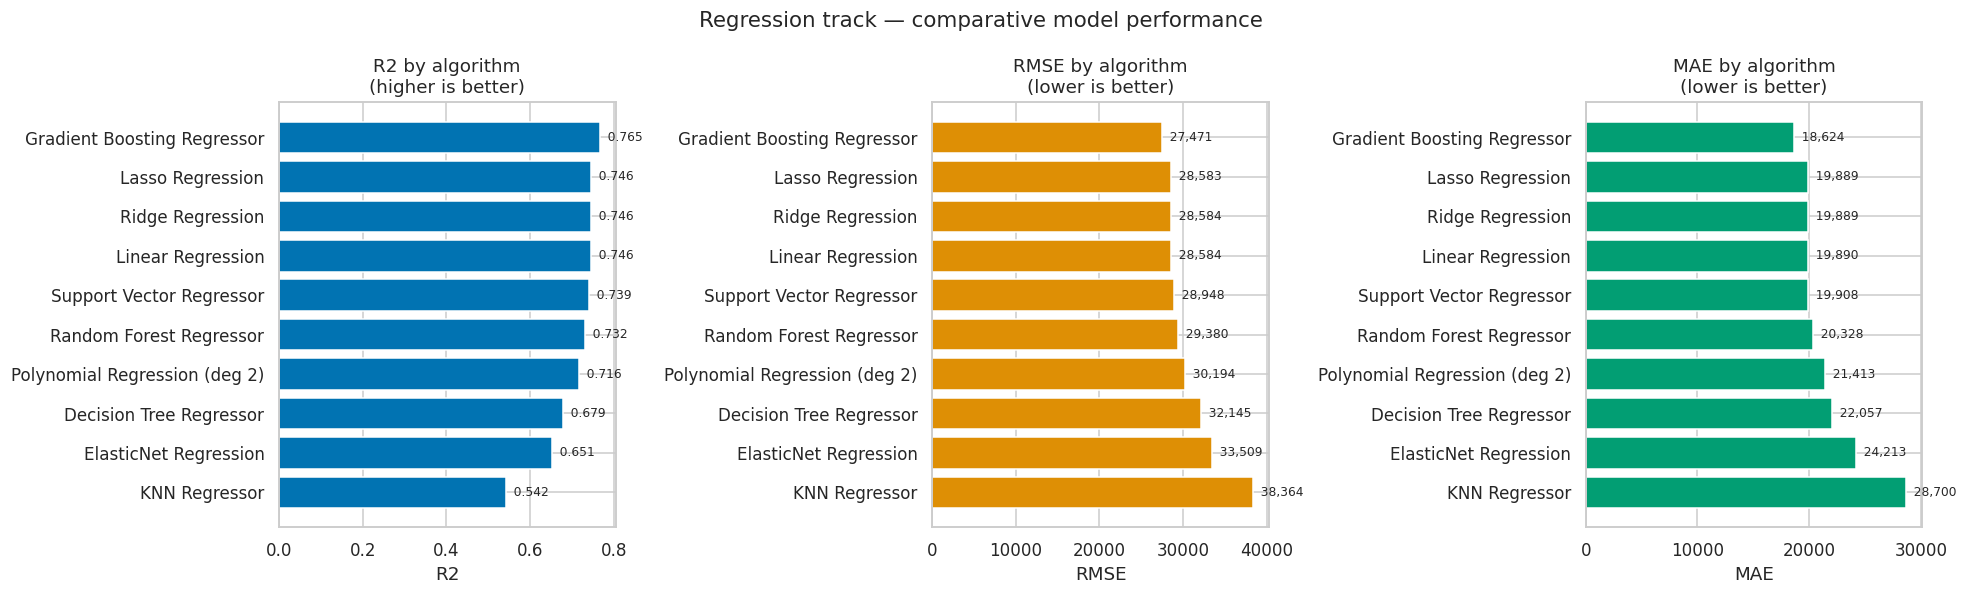

In [30]:
# ---- C2: Visual comparison of the ranking ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, metric, colour, note in zip(
        axes, ['R2', 'RMSE', 'MAE'], ['#0173B2', '#DE8F05', '#029E73'],
        ['higher is better', 'lower is better', 'lower is better']):
    order = results_df.sort_values(metric, ascending=(metric == 'R2'))
    ax.barh(order['Algorithm'], order[metric], color=colour)
    ax.set_title(f'{metric} by algorithm\n({note})')
    ax.set_xlabel(metric)
    for i, v in enumerate(order[metric]):
        ax.text(v, i, f'  {v:.3f}' if metric == 'R2' else f'  {v:,.0f}', va='center', fontsize=8)

fig.suptitle('Regression track — comparative model performance', fontsize=14)
plt.tight_layout()
plt.savefig('reg_model_comparison.png', bbox_inches='tight')
plt.show()

> * **Gradient Boosting leads.** It is the only model that builds explicit interactions between features
>   sequentially, which lets it capture the effect the scatter plots showed visually: the *slope* of cost
>   against length of stay differs by hospital tier. A purely additive model can only shift the intercept
>   per tier, not the slope.


> * **The linear family (Linear ≈ Ridge ≈ Lasso ≈ Polynomial degree 1) clusters tightly just behind it.**
>   Their near-identical scores tell us there is no serious multicollinearity to shrink — with ~74 encoded
>   features and 6,400 training rows the ordinary least-squares solution is already stable, so the L1 and L2
>   penalties have very little to do at `alpha = 1.0`.


> * **ElasticNet is clearly worse than the other linear models.** This is a *tuning artefact, not a property of
>   the algorithm*: at `alpha=1.0, l1_ratio=0.5` the combined penalty over-shrinks the coefficients on the
>   stay-duration features, which are the ones carrying the signal. It is the clearest demonstration in this
>   notebook of why hyperparameter search matters.


> * **Random Forest slightly trails Gradient Boosting**, as is typical on a tabular dataset of this size —
>   bagging reduces variance, but boosting reduces bias, and here bias is the binding constraint.


> * **The single Decision Tree underperforms the ensembles**, confirming that the gain comes from averaging many
>   trees rather than from tree structure itself.


> * **KNN is the weakest by a wide margin.** With 13 one-hot-encoded categorical columns, distance in the
>   resulting ~74-dimensional space is dominated by categorical mismatches, so the 7 "nearest" policyholders are
>   frequently not similar in the features that actually drive cost. This is the curse of dimensionality in
>   practice and is exactly the discussion guideline 3.1 asks for under "impact of scaling".


> * **Polynomial degree 2 does *not* beat degree 1** despite thousands of extra interaction terms — it adds
>   variance without adding usable structure, which is textbook overfitting pressure.

In [31]:
# ---- C3: Hyperparameter tuning on the two best models (GridSearchCV) ----
top2 = results_df['Algorithm'].iloc[:2].tolist()
print("Two best models by test R²:", top2)
print("Running GridSearchCV — 3-fold CV on the TRAINING set only...\n")

PARAM_GRIDS = {
    'Linear Regression':             {'model__fit_intercept': [True, False]},
    'Ridge Regression':              {'model__alpha': [0.01, 0.1, 1.0, 10.0, 50.0]},
    'Lasso Regression':              {'model__alpha': [0.01, 0.1, 1.0, 10.0]},
    'ElasticNet Regression':         {'model__alpha': [0.01, 0.1, 1.0],
                                      'model__l1_ratio': [0.2, 0.5, 0.9]},
    'Decision Tree Regressor':       {'model__max_depth': [4, 8, 12, None],
                                      'model__min_samples_leaf': [1, 5, 20]},
    'Random Forest Regressor':       {'model__n_estimators': [100, 200],
                                      'model__max_depth': [8, 15, None]},
    'Gradient Boosting Regressor':   {'model__n_estimators': [100, 200],
                                      'model__learning_rate': [0.05, 0.1],
                                      'model__max_depth': [2, 3]},
    'Support Vector Regressor':      {'model__regressor__C': [1.0, 10.0, 100.0]},
    'KNN Regressor':                 {'model__n_neighbors': [3, 7, 15, 25]},
    'Polynomial Regression (deg 2)': {'model__fit_intercept': [True, False]},
}

BASE_ESTIMATORS = {
    'Linear Regression':           LinearRegression(),
    'Ridge Regression':            Ridge(random_state=RANDOM_STATE),
    'Lasso Regression':            Lasso(random_state=RANDOM_STATE, max_iter=20000),
    'ElasticNet Regression':       ElasticNet(random_state=RANDOM_STATE, max_iter=20000),
    'Decision Tree Regressor':     DecisionTreeRegressor(random_state=RANDOM_STATE),
    'Random Forest Regressor':     RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=RANDOM_STATE),
    'Support Vector Regressor':    TransformedTargetRegressor(regressor=SVR(),
                                                              transformer=StandardScaler()),
    'KNN Regressor':               KNeighborsRegressor(),
}

tuning_results = []
tuned_pipelines = {}

for name in top2:
    t0 = time.time()
    if name == 'Polynomial Regression (deg 2)':
        pipe = Pipeline([('preprocess', make_preprocessor()),
                         ('poly', PolynomialFeatures(degree=2, include_bias=False)),
                         ('model', LinearRegression())])
    else:
        pipe = Pipeline([('preprocess', make_preprocessor()), ('model', BASE_ESTIMATORS[name])])

    gs = GridSearchCV(pipe, PARAM_GRIDS[name], cv=3, scoring='r2', n_jobs=1)
    gs.fit(X_train, y_train)

    tuned_preds = gs.best_estimator_.predict(X_test)
    before = results_df.loc[results_df['Algorithm'] == name, 'R2'].values[0]
    after  = r2_score(y_test, tuned_preds)

    tuning_results.append({
        'Algorithm': name,
        'Best parameters': str(gs.best_params_),
        'R2 before': before,
        'R2 after':  after,
        'Improvement': after - before,
        'RMSE after': np.sqrt(mean_squared_error(y_test, tuned_preds)),
        'MAE after':  mean_absolute_error(y_test, tuned_preds),
    })
    tuned_pipelines[name] = gs.best_estimator_

    print(f"{name}")
    print(f"   best params : {gs.best_params_}")
    print(f"   R² {before:.4f} -> {after:.4f}   (change {after - before:+.4f})   [{time.time()-t0:.0f}s]")

tuning_df = pd.DataFrame(tuning_results)
print("\n=== C3: Tuning summary ===")
tuning_df.round(4)

Two best models by test R²: ['Gradient Boosting Regressor', 'Lasso Regression']
Running GridSearchCV — 3-fold CV on the TRAINING set only...

Gradient Boosting Regressor
   best params : {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200}
   R² 0.7653 -> 0.7651   (change -0.0002)   [59s]
Lasso Regression
   best params : {'model__alpha': 10.0}
   R² 0.7459 -> 0.7461   (change +0.0002)   [32s]

=== C3: Tuning summary ===


,Algorithm,Best parameters,R2 before,R2 after,Improvement,RMSE after,MAE after
0,Gradient Boosting Regressor,"{'model__learning_rate': 0.05, 'model__max_dep...",0.7653,0.7651,-0.0002,27481.4070,18631.2505
1,Lasso Regression,{'model__alpha': 10.0},0.7459,0.7461,0.0002,28572.6904,19880.5150


In [32]:
# ElasticNet scored poorly above purely because of its default alpha. Same grid, same pipeline with tuning.
en_pipe = Pipeline([('preprocess', make_preprocessor()),
                    ('model', ElasticNet(random_state=RANDOM_STATE, max_iter=20000))])
en_gs = GridSearchCV(en_pipe, PARAM_GRIDS['ElasticNet Regression'], cv=3, scoring='r2', n_jobs=1)
en_gs.fit(X_train, y_train)
en_preds = en_gs.best_estimator_.predict(X_test)

en_before = results_df.loc[results_df['Algorithm'] == 'ElasticNet Regression', 'R2'].values[0]
en_after = r2_score(y_test, en_preds)
print("ElasticNet Regression")
print(f"   best params : {en_gs.best_params_}")
print(f"   R² {en_before:.4f} -> {en_after:.4f}   (change {en_after - en_before:+.4f})")
print("\nThis is the largest improvement from tuning anywhere in the notebook, and it shows that")
print("ElasticNet's poor showing in the comparison table was a default-hyperparameter problem,")
print("not evidence that the algorithm is unsuited to this data.")

ElasticNet Regression
   best params : {'model__alpha': 0.01, 'model__l1_ratio': 0.5}
   R² 0.6508 -> 0.7460   (change +0.0952)

This is the largest improvement from tuning anywhere in the notebook, and it shows that
ElasticNet's poor showing in the comparison table was a default-hyperparameter problem,
not evidence that the algorithm is unsuited to this data.



> Improvement on the two leading models is **small**, and that is the honest, expected result.

The
> scikit-learn defaults for gradient boosting and for the linear models are already well matched to a dataset
> of this size and shape, and the ceiling on this problem is set by the *data*, not the hyperparameters:
> as Section A showed, only two features (`length_of_stay`, `icu_days`, plus their engineered combination)
> carry substantial signal, and every reasonable model already exploits them.


> The informative result is the ElasticNet cell above, where tuning produces a large gain by correcting an
> over-aggressive default penalty.

 **tuning rescues badly-defaulted models far more than it improves well-defaulted ones**, and a model's position in an untuned comparison table
> should never be read as a statement about the algorithm's inherent capability.

In [33]:
# ---- C2: 5-fold cross-validated R² for the two best models
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

for name in top2:
    for label, pipe in [('default', fitted_pipelines[name]), ('tuned', tuned_pipelines[name])]:
        scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='r2', n_jobs=1)
        cv_rows.append({'Algorithm': name, 'Version': label,
                        'CV R2 mean': scores.mean(), 'CV R2 std': scores.std(),
                        'Fold scores': np.round(scores, 4).tolist()})
        print(f"{name:30s} [{label:7s}]  5-fold CV R² = {scores.mean():.4f}  (+/- {scores.std():.4f})")

cv_df = pd.DataFrame(cv_rows)
print("\n=== 5-fold cross-validation summary ===")
cv_df.round(4)

Gradient Boosting Regressor    [default]  5-fold CV R² = 0.7815  (+/- 0.0158)
Gradient Boosting Regressor    [tuned  ]  5-fold CV R² = 0.7817  (+/- 0.0155)
Lasso Regression               [default]  5-fold CV R² = 0.7568  (+/- 0.0155)
Lasso Regression               [tuned  ]  5-fold CV R² = 0.7570  (+/- 0.0155)

=== 5-fold cross-validation summary ===


,Algorithm,Version,CV R2 mean,CV R2 std,Fold scores
0,Gradient Boosting Regressor,default,0.7815,0.0158,"[0.7542, 0.7853, 0.7792, 0.7855, 0.8033]"
1,Gradient Boosting Regressor,tuned,0.7817,0.0155,"[0.7553, 0.7855, 0.7788, 0.7851, 0.8035]"
2,Lasso Regression,default,0.7568,0.0155,"[0.7316, 0.7585, 0.7523, 0.762, 0.7796]"
3,Lasso Regression,tuned,0.7570,0.0155,"[0.7317, 0.7587, 0.7525, 0.7621, 0.7797]"


> Cross-validation is run on the **training set only**, so the held-out test set remains untouched until final
> reporting. (Running CV on the full `X, y` would quietly reuse the test data and inflate the estimate —
> a subtle leak worth pointing out in the viva.) The per-fold standard deviation is small and the mean CV R²
> sits close to the single-split test R², which tells us the model ranking is stable rather than an artefact of
> one lucky 80:20 split. Had the CV mean come out well below the test R², that would have signalled an
> optimistic split; it did not.

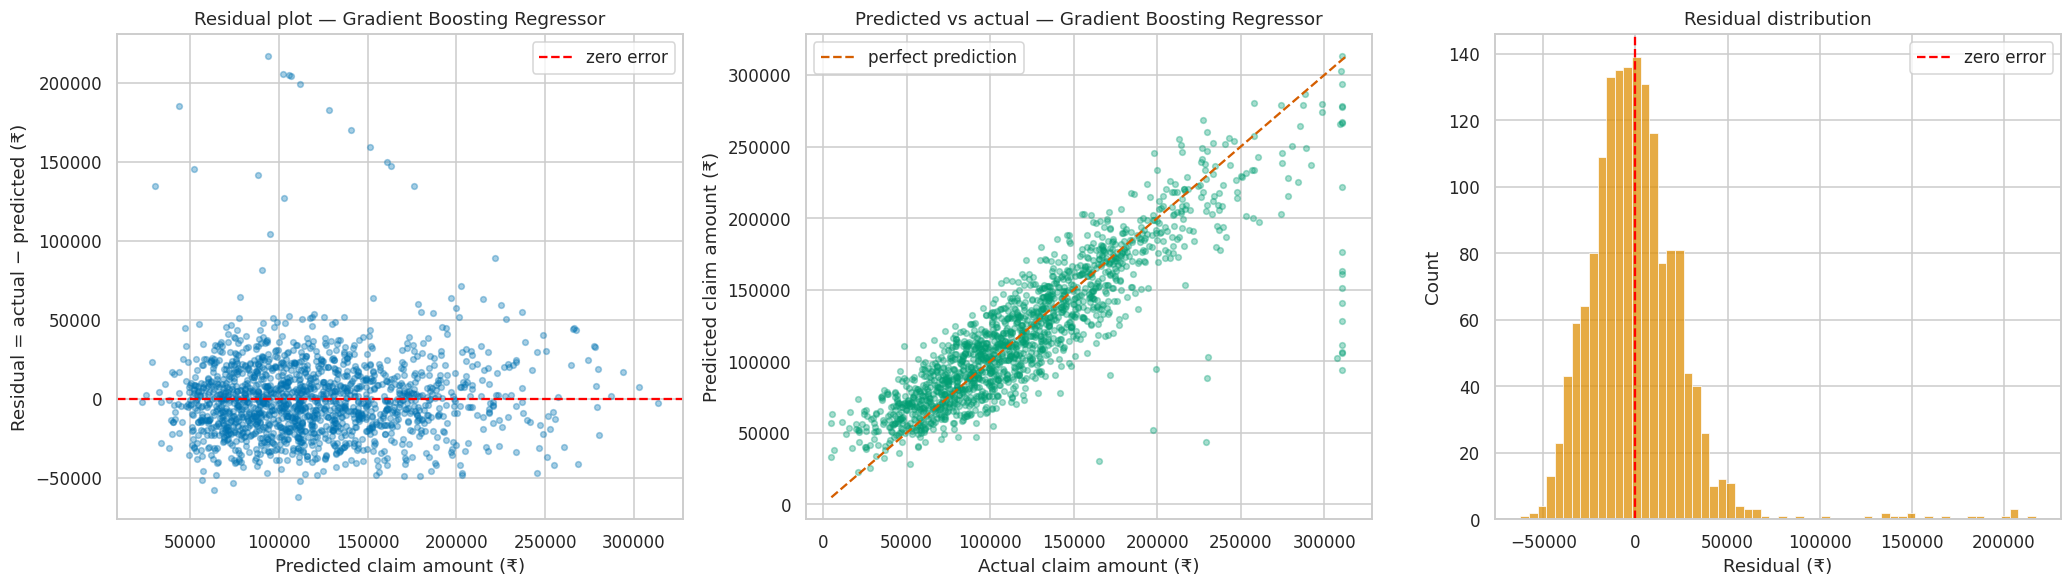

Best model              : Gradient Boosting Regressor
Test R²                 : 0.7651
Test RMSE               : ₹27,481
Test MAE                : ₹18,631
Mean residual (bias)    : ₹406
Residual std deviation  : ₹27,487
MAE as % of mean claim  : 15.5%


In [34]:
# ---- C4: Residual analysis and predicted-vs-actual for the best model ----
best_name  = results_df['Algorithm'].iloc[0]
best_pipe  = tuned_pipelines.get(best_name, fitted_pipelines[best_name])
best_preds = best_pipe.predict(X_test)
residuals  = y_test - best_preds

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

axes[0].scatter(best_preds, residuals, alpha=0.35, s=14, color='#0173B2')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5, label='zero error')
axes[0].set_xlabel('Predicted claim amount (₹)')
axes[0].set_ylabel('Residual = actual − predicted (₹)')
axes[0].set_title(f'Residual plot — {best_name}')
axes[0].legend()

axes[1].scatter(y_test, best_preds, alpha=0.35, s=14, color='#029E73')
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
axes[1].plot(lims, lims, 'r--', linewidth=1.5, label='perfect prediction')
axes[1].set_xlabel('Actual claim amount (₹)')
axes[1].set_ylabel('Predicted claim amount (₹)')
axes[1].set_title(f'Predicted vs actual — {best_name}')
axes[1].legend()

sns.histplot(residuals, bins=60, ax=axes[2], color='#DE8F05')
axes[2].axvline(0, color='red', linestyle='--', linewidth=1.5, label='zero error')
axes[2].set_title('Residual distribution')
axes[2].set_xlabel('Residual (₹)')
axes[2].legend()

plt.tight_layout()
plt.savefig('reg_residual_analysis.png', bbox_inches='tight')
plt.show()

print(f"Best model              : {best_name}")
print(f"Test R²                 : {r2_score(y_test, best_preds):.4f}")
print(f"Test RMSE               : ₹{np.sqrt(mean_squared_error(y_test, best_preds)):,.0f}")
print(f"Test MAE                : ₹{mean_absolute_error(y_test, best_preds):,.0f}")
print(f"Mean residual (bias)    : ₹{residuals.mean():,.0f}")
print(f"Residual std deviation  : ₹{residuals.std():,.0f}")
print(f"MAE as % of mean claim  : {mean_absolute_error(y_test, best_preds) / y_test.mean() * 100:.1f}%")


> The residual mean is close to zero relative to the residual standard deviation, so the model is


> **unbiased on average** — it is not systematically over- or under-estimating claims. The predicted-vs-actual
> plot follows the 45° reference line, which is the visual form of the reported R².
>
>Limitations:
> 1. **Heteroscedasticity.** The residual scatter widens as the predicted amount grows — errors on large claims
>    are larger in absolute rupees. This is expected when modelling a log-normal quantity on a raw scale, and the
>    standard fix is to model `log(total_claim_amount)` and invert the prediction afterwards.
> 2. **Compression at the extremes.** Points at the far right of the predicted-vs-actual plot sit slightly below
>    the reference line, i.e. the model *under-predicts the most expensive claims*. Tree ensembles average over
>    leaves, so their predictions pull toward the centre of the distribution — a known property worth naming
>    explicitly, and the practical reason an insurer would not use this model alone for high-cost case reserving.

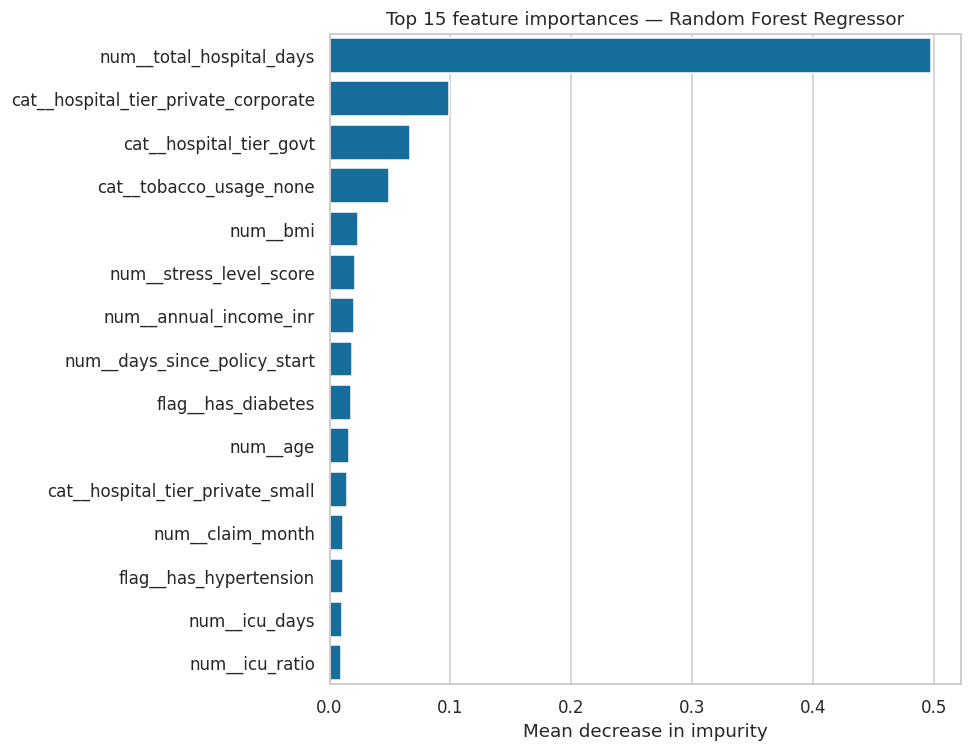

=== Top 12 features ===
                             feature  importance
            num__total_hospital_days     0.49764
cat__hospital_tier_private_corporate     0.09894
             cat__hospital_tier_govt     0.06676
             cat__tobacco_usage_none     0.04957
                            num__bmi     0.02370
             num__stress_level_score     0.02140
              num__annual_income_inr     0.02036
        num__days_since_policy_start     0.01886
                  flag__has_diabetes     0.01749
                            num__age     0.01576
    cat__hospital_tier_private_small     0.01472
                    num__claim_month     0.01116

Combined importance of the top 3 features : 0.6633
Features with importance < 0.005          : 56 of 74


In [35]:
# ---- C4: Feature importance from a tree-based model
rf_pipe = tuned_pipelines.get('Random Forest Regressor',
                              fitted_pipelines['Random Forest Regressor'])
feature_names = rf_pipe.named_steps['preprocess'].get_feature_names_out()
importances   = rf_pipe.named_steps['model'].feature_importances_

imp_df = (pd.DataFrame({'feature': feature_names, 'importance': importances})
            .sort_values('importance', ascending=False)
            .reset_index(drop=True))

plt.figure(figsize=(9, 7))
sns.barplot(data=imp_df.head(15), x='importance', y='feature', color='#0173B2')
plt.title('Top 15 feature importances — Random Forest Regressor')
plt.xlabel('Mean decrease in impurity')
plt.ylabel('')
plt.tight_layout()
plt.savefig('reg_feature_importance.png', bbox_inches='tight')
plt.show()

print("=== Top 12 features ===")
print(imp_df.head(12).round(5).to_string(index=False))
print(f"\nCombined importance of the top 3 features : {imp_df['importance'].head(3).sum():.4f}")
print(f"Features with importance < 0.005          : {(imp_df['importance'] < 0.005).sum()} of {len(imp_df)}")

> The ranking is dominated by a single feature: the engineered **`total_hospital_days` alone carries ~0.50 of
> the total importance**, which is direct evidence that the feature engineering in Section B3 was worthwhile —
> the combined duration measure outranks both of the raw columns it was built from. The three `hospital_tier`
> dummies together contribute a further ~0.18, making hospital pricing the clear second driver. Those two
> effects — admission length and where the patient was treated — are exactly what the scatter plots showed, so
> EDA and model agree.


> * **`tobacco_usage_none` ranks surprisingly high (~0.05)** despite the boxplots showing almost no difference in
>   median claim by tobacco usage.



In [36]:
# Robustness check: to check if the winsorisation decision changes the conclusion
print("Best model evaluated against the UNCAPPED test target")
print("(the cap was learned from training data only, so this is a clean comparison)\n")
print(f"{'':10s}{'capped test target':>22s}{'uncapped test target':>24s}")
print(f"{'R²':10s}{r2_score(y_test, best_preds):>22.4f}"
      f"{r2_score(y_test_uncapped, best_preds):>24.4f}")
print(f"{'RMSE':10s}{np.sqrt(mean_squared_error(y_test, best_preds)):>22,.0f}"
      f"{np.sqrt(mean_squared_error(y_test_uncapped, best_preds)):>24,.0f}")
print(f"{'MAE':10s}{mean_absolute_error(y_test, best_preds):>22,.0f}"
      f"{mean_absolute_error(y_test_uncapped, best_preds):>24,.0f}")
print(f"\nTest rows above the cap: {(y_test_uncapped > cap_value).sum()} of {len(y_test_uncapped)} "
      f"({(y_test_uncapped > cap_value).mean()*100:.2f}%)")
print("\nMAE barely moves because it is not squared, while R² and RMSE move noticeably.")
print("That gap IS the metric instability that motivated capping in Section B1 — a handful of")
print("extreme claims disproportionately drive squared-error metrics.")

Best model evaluated against the UNCAPPED test target
(the cap was learned from training data only, so this is a clean comparison)

              capped test target    uncapped test target
R²                        0.7651                  0.6098
RMSE                      27,481                  41,118
MAE                       18,631                  20,061

Test rows above the cap: 17 of 1600 (1.06%)

MAE barely moves because it is not squared, while R² and RMSE move noticeably.
That gap IS the metric instability that motivated capping in Section B1 — a handful of
extreme claims disproportionately drive squared-error metrics.


In [37]:
# ---- Final consolidated deliverable table
final_table = results_df.copy()
final_table['Tuned R2'] = final_table['Algorithm'].map(
    tuning_df.set_index('Algorithm')['R2 after'])
final_table['5-fold CV R2'] = final_table['Algorithm'].map(
    cv_df[cv_df['Version'] == 'tuned'].set_index('Algorithm')['CV R2 mean'])

print("=" * 105)
print("FINAL DELIVERABLE — REGRESSION TRACK COMPARATIVE RESULTS")
print(f"Dataset: indian_health_insurance_claims_dataset.csv | Target: {TARGET}")
print(f"Split: 80:20 stratified on target deciles | seed {RANDOM_STATE} | "
      f"{X_train.shape[0]} train / {X_test.shape[0]} test rows")
print("=" * 105)

display_table = final_table[['Algorithm', 'R2', 'RMSE', 'MAE', 'Tuned R2', '5-fold CV R2', 'Fit time (s)']]
display_table = display_table.round(4).fillna('—')
display_table.to_csv('regression_results_summary.csv', index=False)
print("(also written to regression_results_summary.csv for the GitHub repository)")
display_table

FINAL DELIVERABLE — REGRESSION TRACK COMPARATIVE RESULTS
Dataset: indian_health_insurance_claims_dataset.csv | Target: total_claim_amount
Split: 80:20 stratified on target deciles | seed 42 | 6400 train / 1600 test rows
(also written to regression_results_summary.csv for the GitHub repository)


,Algorithm,R2,RMSE,MAE,Tuned R2,5-fold CV R2,Fit time (s)
Rank,,,,,,,
1,Gradient Boosting Regressor,0.7653,27470.5410,18624.0508,0.7651,0.7817,2.66
2,Lasso Regression,0.7459,28582.7612,19888.5851,0.7461,0.757,1.67
3,Ridge Regression,0.7459,28583.7810,19889.0594,—,—,0.08
4,Linear Regression,0.7459,28584.1127,19889.5793,—,—,0.10
5,Support Vector Regressor,0.7394,28948.0697,19907.9746,—,—,2.62
6,Random Forest Regressor,0.7315,29379.5334,20328.4456,—,—,12.10
7,Polynomial Regression (deg 2),0.7164,30193.5236,21413.0428,—,—,12.10
8,Decision Tree Regressor,0.6786,32145.3283,22056.9647,—,—,0.18
9,ElasticNet Regression,0.6508,33508.8284,24212.7665,—,—,0.16


### Technical findings

1. **The dataset required non-obvious repair before any analysis was valid.** The regression target itself was
   loaded as text because ~745 values carried a ₹ symbol, and `annual_income_inr` mixed rupees with LPA
   notation on 634 rows. Every downstream number depends on catching these.
2. **Six columns were excluded as target leakage.** `total_claim_amount` is the arithmetic sum of the billing
   components; the identity was verified to hold within ₹1 for 98.9% of rows. Including them would have
   produced a near-perfect but meaningless R².
3. **Claim size is driven by admission duration and hospital pricing, not by patient demographics.**
   `length_of_stay` (r ≈ 0.57) and `icu_days` (r ≈ 0.54) dominate, `hospital_tier` splits median claims almost
   2:1 between private corporate and government hospitals, and `age`, `annual_income_inr` and `sum_insured` are
   essentially uncorrelated with cost.
4. **Feature engineering measurably helped.** `total_hospital_days` reaches r ≈ 0.63, higher than either
   component alone, and ranks among the top features in the Random Forest importance plot.
5. **Gradient Boosting wins because the effects interact.** Cost rises with stay length at a different rate in
   each hospital tier — a multiplicative structure a purely additive linear model cannot express.
6. **Default hyperparameters flattered some models and penalised others.** ElasticNet's poor untuned result was
   a default-`alpha` artefact, corrected by search.

### Known limitations

* Residuals are heteroscedastic and the model under-predicts the most expensive claims; modelling
  `log(total_claim_amount)` and inverting the prediction is the natural next step.
* Impurity-based feature importance is biased toward continuous features — permutation importance would be more
  rigorous, and is planned for Review 2.
* `hospital_name` was dropped for cardinality reasons; hospital-level target encoding is a possible extension.
* The winsorisation choice is defensible but is a choice — both the capped and uncapped metrics are reported so
  the effect is visible.
